In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.lines as mlines
import seaborn as sns
from scipy.spatial import procrustes
import zarr
import pandas as pd
import re
import tqdm
import matplotlib.patches as patches
base_dir = '/scratch/gpfs/AKEY/apfennig/'

### Process datasets to get allele frequency on intersection of call sets (needs to be run only once)

In [2]:
# load all sample sets
pangenie_calls = zarr.open_group(f'{base_dir}HGSVC3/pangenie_chm13_all_decomposed_lenient.vcz/')
giggles_calls =  zarr.open_group(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased.vcz/')
srwgs_calls = zarr.open_group(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr21.filtered.SNV_INDEL_SV_phased_panel.biallelic.vcz/')

pangenie_sample_ids = pangenie_calls['sample_id'][:]
giggles_sample_ids = giggles_calls['sample_id'][:]
srwgs_sample_ids = srwgs_calls['sample_id'][:]

sample_ids, sample_id_counts = np.unique(np.concatenate([pangenie_sample_ids, giggles_sample_ids, srwgs_sample_ids]),
                                         return_counts=True)
shared_sample_ids = sample_ids[sample_id_counts == 3]

pangenie_sample_mask = np.isin(pangenie_sample_ids, shared_sample_ids)
giggles_sample_mask = np.isin(giggles_sample_ids, shared_sample_ids)
srwgs_sample_mask = np.isin(srwgs_sample_ids, shared_sample_ids)

np.savez(f'{base_dir}HGSVC3/pangenie_shared_sample_ids.npz', pangenie_sample_ids[pangenie_sample_mask])
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_shared_sample_ids.npz', giggles_sample_ids[giggles_sample_mask])
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_shared_sample_ids.npz', srwgs_sample_ids[srwgs_sample_mask])




In [4]:
# get var ids
pangenie_variant_ids = pangenie_calls['variant_id'][:]
giggles_variant_ids = giggles_calls['variant_id'][:]

# get variant alleles
pangenie_variant_alleles = pangenie_calls['variant_allele'][:]
giggles_variant_alleles = giggles_calls['variant_allele'][:]

# parse variant type from variant id
pangenie_variant_types = np.array([vid.split('-')[2] for vid in pangenie_variant_ids])
giggles_variant_types = np.array([vid.split('-')[2] for vid in giggles_variant_ids])

# parse variant size from variant id
pangenie_variant_sizes = np.array([int(vid.split('-')[4]) for vid in pangenie_variant_ids])
giggles_variant_sizes = np.array([int(vid.split('-')[4]) for vid in giggles_variant_ids])

np.savez(f'{base_dir}HGSVC3/pangenie_variant_ids.npz', pangenie_variant_ids)
np.savez(f'{base_dir}HGSVC3/pangenie_variant_alleles.npz', pangenie_variant_alleles)
np.savez(f'{base_dir}HGSVC3/pangenie_variant_types.npz', pangenie_variant_types)
np.savez(f'{base_dir}HGSVC3/pangenie_variant_sizes.npz', pangenie_variant_sizes)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_ids.npz', giggles_variant_ids)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_alleles.npz', giggles_variant_alleles)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_types.npz', giggles_variant_types)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_sizes.npz', giggles_variant_sizes)


srwgs_all_var_ids = []
srwgs_all_var_types = []
srwgs_all_var_alleles = []
srwgs_all_var_sizes = []
for chrom in np.arange(1, 23):
    print(chrom)
    srwgs_calls = zarr.open_group(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr{chrom}.filtered.SNV_INDEL_SV_phased_panel.biallelic.vcz/')
    srwgs_variant_ids = srwgs_calls['variant_id'][:]
    srwgs_variant_alleles = srwgs_calls['variant_allele'][:][:, :2]
    srwgs_variant_provided_types = np.array(['SV' if max(len(a[0]), len(a[1])) >= 50 else 
                                             'INDEL' if 1 < max(len(a[0]), len(a[1])) < 50 
                                             else 'SNV' 
                                             for a in srwgs_variant_alleles])
    srwgs_variant_ends = srwgs_calls['variant_END'][:]
    srwgs_variant_positions = srwgs_calls['variant_position'][:]
    srwgs_variant_provided_svtypes = srwgs_calls['variant_SVTYPE'][:]
    srwgs_variant_provided_sizes = srwgs_calls['variant_SVLEN'][:]
    srwgs_variant_sizes = np.zeros(srwgs_variant_alleles.shape[0])
    srwgs_variant_types = np.zeros(srwgs_variant_alleles.shape[0]).astype(str)

    for i, vt in enumerate(srwgs_variant_provided_types):
#         if i == 4622:
#             import pdb; pdb.set_trace()
        if vt == 'SNV':
            srwgs_variant_types[i] = 'SNV'
            srwgs_variant_sizes[i] = 1
        elif vt == 'INDEL' and srwgs_variant_ends[i] != -1:
            allele_a = srwgs_variant_alleles[i][0]
            allele_b = srwgs_variant_alleles[i][1]
            if max([len(allele_a), len(allele_b)]) == 1:
                srwgs_variant_sizes[i] = 1
                srwgs_variant_types[i] = 'SNV'
            else:
                if srwgs_variant_provided_sizes[i] != -1:
                    srwgs_variant_sizes[i] = np.abs(srwgs_variant_provided_sizes[i])
                else:
                    srwgs_variant_sizes[i] = srwgs_variant_ends[i] - srwgs_variant_positions[i] + 1
                if len(allele_a) > len(allele_b) or 'DEL' in allele_b:
                    srwgs_variant_types[i] = 'DEL'
                elif len(allele_b) > len(allele_a) or 'INS' in allele_b or 'DUP' in allele_b:
                    srwgs_variant_types[i] = 'INS'
                elif len(allele_b) > len(allele_a) or 'INV' in allele_b:
                    srwgs_variant_types[i] = 'COMPLEX'
                else:
                    print(i)
        elif vt == 'INDEL' and srwgs_variant_ends[i] == -1:
            allele_a = srwgs_variant_alleles[i][0]
            allele_b = srwgs_variant_alleles[i][1]
            if len(allele_a) - len(allele_b) > 0 and min([len(allele_a), len(allele_b)]) == 1:
                if srwgs_variant_provided_sizes[i] != -1:
                    srwgs_variant_size[i] = np.abs(srwgs_variant_provided_sizes[i])
                else:
                    srwgs_variant_sizes[i] = len(allele_a) - len(allele_b)
                srwgs_variant_types[i] = 'DEL'
            elif len(allele_a) - len(allele_b) < 0 and min([len(allele_a), len(allele_b)]) == 1: 
                if srwgs_variant_provided_sizes[i] != -1:
                    srwgs_variant_size[i] = np.abs(srwgs_variant_provided_sizes[i])
                else:
                    srwgs_variant_sizes[i] = len(allele_b) - len(allele_a)
                srwgs_variant_types[i] = 'INS'
            elif max([len(allele_a), len(allele_b)]) == 1:
                srwgs_variant_sizes[i] = 1
                srwgs_variant_types[i] = 'SNV'
            else:
                if srwgs_variant_provided_sizes[i] != -1:
                    srwgs_variant_size[i] = np.abs(srwgs_variant_provided_sizes[i])
                else:
                    srwgs_variant_sizes[i] = max([len(allele_a), len(allele_b)])
                srwgs_variant_types[i] = 'COMPLEX'
        elif vt == 'SV' and srwgs_variant_ends[i] == -1:
            allele_a = srwgs_variant_alleles[i][0]
            allele_b = srwgs_variant_alleles[i][1]
            if 'INS' in srwgs_variant_alleles[i][1]:
                srwgs_variant_sizes[i] = srwgs_variant_provided_sizes[i]
                srwgs_variant_types[i] = 'INS'
            elif re.fullmatch(r"[ACGT]+", allele_a) and re.fullmatch(r"[ACGT]+", allele_b):
                if "INS" in allele_b or 'DUP' in allele_b or 'DEL' in allele_b or "INS" in allele_b:
                    print(i)
                elif len(allele_a) < len(allele_b):
                    if srwgs_variant_provided_sizes[i] != -1:
                        srwgs_variant_size[i] = np.abs(srwgs_variant_provided_sizes[i])
                    else:
                        srwgs_variant_sizes[i] = len(allele_b)
                    srwgs_variant_types[i] = 'INS'
                elif len(allele_a) > len(allele_b):
                    if srwgs_variant_provided_sizes[i] != -1:
                        srwgs_variant_size[i] = np.abs(srwgs_variant_provided_sizes[i])
                    else:
                        srwgs_variant_sizes[i] = len(allele_b)
                    srwgs_variant_types[i] = 'DEL'
                else:
                    print(i)
            else:
                print(i)
        elif vt == 'SV' and srwgs_variant_ends[i] != -1:
            if srwgs_variant_provided_sizes[i] == -1:
                length = srwgs_variant_ends[i] - srwgs_variant_positions[i] + 1
            else:
                length = np.abs(srwgs_variant_provided_sizes[i])
            allele_a = srwgs_variant_alleles[i][0]
            allele_b = srwgs_variant_alleles[i][1]
            if max([len(allele_a), len(allele_b)]) == 1:
                print(i)
                srwgs_variant_sizes[i] = 1
                srwgs_variant_types[i] = 'SNV'
            if srwgs_variant_provided_svtypes[i] == 'CNV':
                srwgs_variant_types[i] = 'INS'
                srwgs_variant_sizes[i] = length
            elif srwgs_variant_provided_svtypes[i] == 'DEL':
                srwgs_variant_types[i] = 'DEL'
                srwgs_variant_sizes[i] = length
            elif srwgs_variant_provided_svtypes[i] == 'DUP':
                srwgs_variant_types[i] = 'INS'
                srwgs_variant_sizes[i] = length
            elif srwgs_variant_provided_svtypes[i] == 'INS':
                srwgs_variant_types[i] = 'INS'
                srwgs_variant_sizes[i] = length
            elif srwgs_variant_provided_svtypes[i] == 'INV':
                srwgs_variant_types[i] = 'COMPLEX'
                srwgs_variant_sizes[i] = length
            else:
                print(i)
        else: 
            print(i)
    srwgs_all_var_ids.append(srwgs_variant_ids)
    srwgs_all_var_types.append(srwgs_variant_types)
    srwgs_all_var_alleles.append(srwgs_variant_alleles)
    srwgs_all_var_sizes.append(srwgs_variant_sizes)

srwgs_variant_ids = np.concatenate(srwgs_all_var_ids)
srwgs_variant_types = np.concatenate(srwgs_all_var_types)
srwgs_variant_sizes = np.concatenate(srwgs_all_var_sizes)
srwgs_variant_alleles = np.vstack(srwgs_all_var_alleles)


np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_ids.npz', srwgs_variant_ids)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_alleles.npz', srwgs_variant_alleles)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_types.npz', srwgs_variant_types)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_sizes.npz', srwgs_variant_sizes)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22


In [5]:
def calculate_allele_frequencies(gt, sample_mask, chunk_size=100000):

    n_variants = gt.shape[0]

    allele_counts = []
    allele_numbers = []
    allele_freqs = []

    for start in tqdm.tqdm(range(0, n_variants, chunk_size)):
        end = min(start + chunk_size, n_variants)

        gt_chunk = gt[start:end, sample_mask, :]
        gt_chunk = np.where(gt_chunk < 0, np.nan, gt_chunk)
        # now shape = (chunk_variants, kept_samples, ploidy)

        mask = gt_chunk >= 0
        
        ac = np.sum(gt_chunk == 1, axis=(1,2))
        an = np.sum(mask, axis=(1,2))

        af = ac / an

        allele_counts.append(ac)
        allele_numbers.append(an)
        allele_freqs.append(af)

    allele_counts = np.concatenate(allele_counts)
    allele_freqs = np.concatenate(allele_freqs)
    allele_numbers = np.concatenate(allele_numbers)
    return allele_freqs, allele_counts, allele_numbers

pangenie_gt = pangenie_calls["call_genotype"]
giggles_gt = giggles_calls["call_genotype"]

pangenie_af, pangenie_ac, pangenie_an = calculate_allele_frequencies(pangenie_gt, pangenie_sample_mask)
giggles_af, giggles_ac, giggles_an = calculate_allele_frequencies(giggles_gt, giggles_sample_mask)

srwgs_af = []
srwgs_ac = []
srwgs_an = []
for chrom in np.arange(1, 23):
    srwgs_calls = zarr.open_group(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr{chrom}.filtered.SNV_INDEL_SV_phased_panel.biallelic.vcz/')
    srwgs_gt = srwgs_calls['call_genotype']
    af, ac, an = calculate_allele_frequencies(srwgs_gt, srwgs_sample_mask)
    srwgs_af.append(af)
    srwgs_ac.append(ac)
    srwgs_an.append(an)
srwgs_af = np.concatenate(srwgs_af)
srwgs_ac = np.concatenate(srwgs_ac)
srwgs_an = np.concatenate(srwgs_an)

    
np.savez(f'{base_dir}HGSVC3/pangenie_variant_af.npz', pangenie_af)
np.savez(f'{base_dir}HGSVC3/pangenie_variant_ac.npz', pangenie_ac)
np.savez(f'{base_dir}HGSVC3/pangenie_variant_an.npz', pangenie_an)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_af.npz', giggles_af)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_ac.npz', giggles_ac)
np.savez(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_an.npz', giggles_an)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_af.npz', srwgs_af)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_ac.npz', srwgs_ac)
np.savez(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_an.npz', srwgs_an)

  0%|          | 0/58 [00:00<?, ?it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 320


100%|██████████| 11/11 [00:31<00:00,  2.88s/it]


### Load processed datasets

In [4]:
shared_sample_ids = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_shared_sample_ids.npz', 
                            allow_pickle=True)['arr_0']
pangenie_af = np.load(f'{base_dir}HGSVC3/pangenie_variant_af.npz')['arr_0']
pangenie_ac = np.load(f'{base_dir}HGSVC3/pangenie_variant_ac.npz')['arr_0']
pangenie_an = np.load(f'{base_dir}HGSVC3/pangenie_variant_an.npz')['arr_0']
pangenie_variant_types = np.load(f'{base_dir}HGSVC3/pangenie_variant_types.npz')['arr_0']
pangenie_variant_sizes = np.load(f'{base_dir}HGSVC3/pangenie_variant_sizes.npz')['arr_0']

pangenie_af = pangenie_af[pangenie_an == shared_sample_ids.shape[0] * 2]
pangenie_ac = pangenie_ac[pangenie_an == shared_sample_ids.shape[0] * 2]
pangenie_variant_types = pangenie_variant_types[pangenie_an == shared_sample_ids.shape[0] * 2]
pangenie_variant_sizes = pangenie_variant_sizes[pangenie_an == shared_sample_ids.shape[0] * 2]
pangenie_an = pangenie_an[pangenie_an == shared_sample_ids.shape[0] * 2]

giggles_af = np.load(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_af.npz')['arr_0']
giggles_ac = np.load(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_ac.npz')['arr_0']
giggles_an = np.load(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_an.npz')['arr_0']
giggles_variant_types = np.load(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_types.npz')['arr_0']
giggles_variant_sizes = np.load(f'{base_dir}1KGP_ONT_VIENNA/giggles_variant_sizes.npz')['arr_0']

giggles_af = giggles_af[giggles_an == shared_sample_ids.shape[0] * 2]
giggles_ac = giggles_ac[giggles_an == shared_sample_ids.shape[0] * 2]
giggles_variant_types = giggles_variant_types[giggles_an == shared_sample_ids.shape[0] * 2]
giggles_variant_sizes = giggles_variant_sizes[giggles_an == shared_sample_ids.shape[0] * 2]
giggles_an = giggles_an[giggles_an == shared_sample_ids.shape[0] * 2]


srwgs_af = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_af.npz')['arr_0']
srwgs_ac = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_ac.npz')['arr_0']
srwgs_an = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_an.npz')['arr_0']
srwgs_variant_types = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_types.npz')['arr_0']
srwgs_variant_sizes = np.load(f'{base_dir}1kgp_high_coverage_hg38/srwgs_variant_sizes.npz')['arr_0']

srwgs_af = srwgs_af[srwgs_an == shared_sample_ids.shape[0] * 2]
srwgs_ac = srwgs_ac[srwgs_an == shared_sample_ids.shape[0] * 2]
srwgs_variant_types = srwgs_variant_types[srwgs_an == shared_sample_ids.shape[0] * 2]
srwgs_variant_sizes = srwgs_variant_sizes[srwgs_an == shared_sample_ids.shape[0] * 2]
srwgs_an = srwgs_an[srwgs_an == shared_sample_ids.shape[0] * 2]

In [3]:
def expected_sfs(gamma, n, folded=False):
    """
    Expected SFS under the Poisson random field model (Sawyer & Hartl 1992).
 
    Parameters
    ----------
    gamma : float
        Scaled selection coefficient (2*Ne*s). Negative = purifying selection.
    n     : int
        Sample size in haplotypes.
    folded : bool
        If True, return the folded (minor allele) SFS.
 
    Returns
    -------
    counts : np.ndarray, shape (n-1,)
        Allele counts 1..n-1.
    sfs    : np.ndarray, shape (n-1,)
        Normalised expected SFS (sums to 1).
    """
    i = np.arange(1, n)
    x = i / n
 
    if abs(gamma) < 1e-6:
        f = 1.0 / x                          # neutral: f(x) ∝ 1/x
    else:
        g2 = 2.0 * gamma
        numerator   = 1.0 - np.exp(-g2 * (1.0 - x))
        denominator = x   * (1.0 - np.exp(-g2))
        f = numerator / denominator
        f = np.clip(f, 0, None)
 
    if folded:
        mid = n // 2
        f_folded = np.zeros(mid)
        for k in range(1, mid + 1):
            val = f[k - 1]
            if k != n - k:
                val += f[n - k - 1]
            f_folded[k - 1] = val
        f = f_folded
        i = np.arange(1, mid + 1)
 
    sfs = f / f.sum()
    return sfs

## Plot SFS

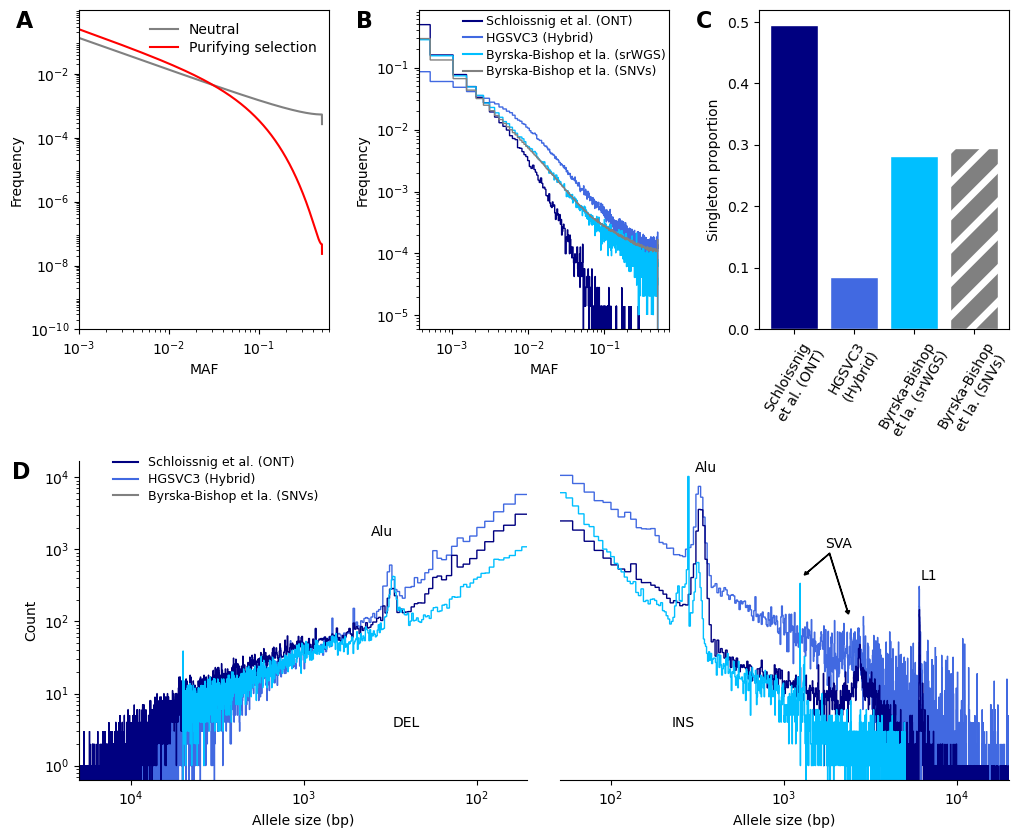

In [4]:
fig = plt.figure(figsize=(12, 10))

gs = GridSpec(7, 33, figure=fig)  # 2 rows, 2 columns

ax1 = fig.add_subplot(gs[:3, 12:21])
ax2 = fig.add_subplot(gs[:3, 24:])
ax5 = fig.add_subplot(gs[:3, :9])
ax3 = fig.add_subplot(gs[4:, :16])
ax4 = fig.add_subplot(gs[4:, 17:], sharey=ax3)

bins = np.linspace(0, 0.5, shared_sample_ids.shape[0])
pangenie_sv_maf = np.where(pangenie_af[pangenie_variant_sizes >= 50] > 0.5, 
                           1 - pangenie_af[pangenie_variant_sizes >= 50], 
                           pangenie_af[pangenie_variant_sizes >= 50])
giggles_sv_maf = np.where(giggles_af[giggles_variant_sizes >= 50] > 0.5, 
                           1 - giggles_af[giggles_variant_sizes >= 50], 
                           giggles_af[giggles_variant_sizes >= 50])
srwgs_sv_maf = np.where(srwgs_af[srwgs_variant_sizes >= 50] > 0.5, 
                           1 - srwgs_af[srwgs_variant_sizes >= 50], 
                           srwgs_af[srwgs_variant_sizes >= 50])

pangenie_sv_sizes = pangenie_variant_sizes[(pangenie_variant_sizes >= 50)][(pangenie_sv_maf > 0)]
giggles_sv_sizes = giggles_variant_sizes[(giggles_variant_sizes >= 50)][(giggles_sv_maf > 0)]
srwgs_sv_sizes = srwgs_variant_sizes[(srwgs_variant_sizes >= 50)][(srwgs_sv_maf > 0)]

pangenie_sv_types = pangenie_variant_types[(pangenie_variant_sizes >= 50)][(pangenie_sv_maf > 0)]
giggles_sv_types = giggles_variant_types[(giggles_variant_sizes >= 50)][(giggles_sv_maf > 0)]
srwgs_sv_types = srwgs_variant_types[(srwgs_variant_sizes >= 50)][(srwgs_sv_maf > 0)]

pangenie_sv_maf = pangenie_sv_maf[pangenie_sv_maf > 0]
giggles_sv_maf = giggles_sv_maf[giggles_sv_maf > 0]
srwgs_sv_maf = srwgs_sv_maf[srwgs_sv_maf > 0]

pangenie_snv_maf = np.where(pangenie_af[pangenie_variant_sizes == 1] > 0.5, 
                           1 - pangenie_af[pangenie_variant_sizes == 1], 
                           pangenie_af[pangenie_variant_sizes == 1])
giggles_snv_maf = np.where(giggles_af[giggles_variant_sizes == 1] > 0.5, 
                           1 - giggles_af[giggles_variant_sizes == 1], 
                           giggles_af[giggles_variant_sizes == 1])
srwgs_snv_maf = np.where(srwgs_af[srwgs_variant_sizes == 1] > 0.5, 
                           1 - srwgs_af[srwgs_variant_sizes == 1], 
                           srwgs_af[srwgs_variant_sizes == 1])

pangenie_snv_maf = pangenie_snv_maf[pangenie_snv_maf > 0]
giggles_snv_maf = giggles_snv_maf[giggles_snv_maf > 0]
srwgs_snv_maf = srwgs_snv_maf[srwgs_snv_maf > 0]


ax1.hist(giggles_sv_maf, bins=bins, weights = np.repeat(1 / giggles_sv_maf.shape[0], giggles_sv_maf.shape[0]),
        histtype='step', color='navy', label='Giggles')
ax1.hist(pangenie_sv_maf, bins=bins, weights = np.repeat(1 / pangenie_sv_maf.shape[0], pangenie_sv_maf.shape[0]),
        histtype='step', color='royalblue', label='Pangenie')
ax1.hist(srwgs_sv_maf, bins=bins, weights = np.repeat(1 / srwgs_sv_maf.shape[0], srwgs_sv_maf.shape[0]),
        histtype='step', color='deepskyblue', label='srWGS')
ax1.hist(srwgs_snv_maf, bins=bins, weights = np.repeat(1 / srwgs_snv_maf.shape[0], srwgs_snv_maf.shape[0]),
        histtype='step', color='grey', label='srWGS', ls='-')

maf_thresh = 1 / (2 * shared_sample_ids.shape[0])

ax2.bar([1, 2, 3, 4], 
          [np.isclose(giggles_sv_maf - maf_thresh, 0).sum() / giggles_sv_maf.shape[0],
           np.isclose(pangenie_sv_maf - maf_thresh, 0).sum() / pangenie_sv_maf.shape[0],
           np.isclose(srwgs_sv_maf - maf_thresh, 0).sum() / srwgs_sv_maf.shape[0],
           np.isclose(srwgs_snv_maf - maf_thresh, 0).sum() / srwgs_snv_maf.shape[0]],
          color=['navy', 'royalblue', 'deepskyblue', 'grey'], hatch=['', '', '', '/'], 
          hatch_linewidth=5, edgecolor='white')

ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Schloissnig\net al. (ONT)', 'HGSVC3\n(Hybrid)', 'Byrska-Bishop\net la. (srWGS)', 
                     'Byrska-Bishop\net la. (SNVs)'], 
                    rotation=60)
ax2.set_ylabel('Singleton proportion')

ax5.plot(np.arange(1, 501) / 1000, expected_sfs(0, 1000, folded=True), color='grey',
         label='Neutral')

ax5.plot(np.arange(1, 501) / 1000, expected_sfs(-10, 1000, folded=True),
         color='red',
         label='Purifying selection')

# ax5.plot(np.arange(1, 1000) / 1000, expected_sfs(100, 1000),
#          color='blue',
#          label='Positive selection')
ax5.set_ylim([10 ** -10, 0.99])
ax5.set_xlim([1 / 1000, 0.6])

ax5.legend(loc='upper right', frameon=False, labelspacing=0.3)

ax5.set_xlabel("MAF")
ax5.set_ylabel("Frequency")
ax5.set_xscale('log')
ax5.set_yscale('log')
minor_ticks = []
for exp in range(-10, 0):
    for sub in [2, 3, 4, 5, 6, 7, 8, 9]:
        minor_ticks.append(sub * 10**exp)

ax5.yaxis.set_minor_locator(plt.FixedLocator(minor_ticks))
ax5.yaxis.set_minor_formatter(plt.NullFormatter())

# ax5.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 3, 4, 5, 6, 7, 8, 9], numticks=5))




# ax.hist(giggles_snv_maf, bins=bins, weights = np.repeat(1 / giggles_snv_maf.shape[0], giggles_snv_maf.shape[0]),
#         histtype='step', color='navy', label='Giggles', ls='--')
# ax.hist(pangenie_snv_maf, bins=bins, weights = np.repeat(1 / pangenie_snv_maf.shape[0], pangenie_snv_maf.shape[0]),
#         histtype='step', color='royalblue', label='Pangenie', ls='--')
# ax.hist(srwgs_snv_maf, bins=bins, weights = np.repeat(1 / srwgs_snv_maf.shape[0], srwgs_snv_maf.shape[0]),
#         histtype='step', color='deepskyblue', label='srWGS', ls='--')

ax1.set_xlabel("MAF")
ax1.set_ylabel('Frequency')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.text(-0.25, 1, 'B', transform=ax1.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')
ax2.text(-0.25, 1, 'C', transform=ax2.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')
ax5.text(-0.25, 1, 'A', transform=ax5.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')


ax4.hist(pangenie_sv_sizes[pangenie_sv_types == 'INS'], bins=5000, range=(50, 50000),  
           histtype='step', color='royalblue')
ax3.hist(pangenie_sv_sizes[pangenie_sv_types == 'DEL'], bins=5000, range=(50, 50000), histtype='step',
           color='royalblue')
ax4.hist(giggles_sv_sizes[giggles_sv_types == 'INS'], bins=5000, range=(50, 50000),  histtype='step',
           color='navy')
ax3.hist(giggles_sv_sizes[giggles_sv_types == 'DEL'], bins=5000, range=(50, 50000), histtype='step',
            color='navy')
ax4.hist(srwgs_sv_sizes[srwgs_sv_types == 'INS'], bins=1000, range=(50, 5000),  histtype='step',
            color='deepskyblue')
ax3.hist(srwgs_sv_sizes[srwgs_sv_types == 'DEL'], bins=1000, range=(50, 5000), histtype='step',
            color='deepskyblue')


# ax.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim([51, 20000])
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.invert_xaxis()
ax4.set_yscale('log')
ax4.set_xlim([51, 20000])
ax4.spines['left'].set_visible(False)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

ax3.set_xscale('symlog', linthresh=0.1, linscale=1)
ax4.set_xscale('symlog', linthresh=0.1, linscale=1)
ax4.get_yaxis().set_visible(False)

ax3.text(0.65, 0.8, 'Alu', transform=ax3.transAxes,
           fontsize=10, va='top', ha='left')
ax4.text(0.35, 1, 'Alu', transform=ax4.transAxes,
           fontsize=10, va='top', ha='right')
ax4.text(0.65, 0.76, 'SVA', transform=ax4.transAxes,
           fontsize=10, va='top', ha='right')
ax4.arrow(0.6, 0.71, 0.04, -.18, head_length=0.01, head_width=0.01, 
          transform=ax4.transAxes, fc ='black', ec ='black')
ax4.arrow(0.6, 0.71, -0.05, -.06, head_length=0.01, head_width=0.01, 
          transform=ax4.transAxes, fc ='black', ec ='black')
ax4.text(0.84, 0.66, 'L1', transform=ax4.transAxes,
           fontsize=10, va='top', ha='right')


ax3.text(0.7, 0.2, 'DEL', transform=ax3.transAxes,
           fontsize=10, va='top', ha='left')
ax4.text(0.3, 0.2, 'INS', transform=ax4.transAxes,
           fontsize=10, va='top', ha='right')
ax3.text(-0.15, 1, 'D', transform=ax3.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

handles = [Line2D([0], [0], color='navy', label='Schloissnig et al. (ONT)'),
           Line2D([0], [0], color='royalblue', label='HGSVC3 (Hybrid)'),
           Line2D([0], [0], color='grey', label='Byrska-Bishop et la. (SNVs)')]
ax3.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.05, 1.05), 
           ncol=1, frameon=False, fontsize=9, labelspacing=0.3)

handles = [Line2D([0], [0], color='navy', label='Schloissnig et al. (ONT)'),
           Line2D([0], [0], color='royalblue', label='HGSVC3 (Hybrid)'),
           Line2D([0], [0], color='deepskyblue', label='Byrska-Bishop et la. (srWGS)'),
           Line2D([0], [0], color='grey', label='Byrska-Bishop et la. (SNVs)')]

ax1.legend(handles=handles, loc='upper right', handletextpad=0.3, handlelength=1.5,
           bbox_to_anchor=(1.03, 1.02), 
           ncol=1, frameon=False, fontsize=9, labelspacing=0.3)
ax3.set_xlabel('Allele size (bp)')
ax3.set_ylabel('Count')

ax4.set_xlabel('Allele size (bp)')
fig.savefig('sfs.pdf', dpi=600, bbox_inches='tight')

## Load PCAs

In [8]:
eigenvec_sv = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_svs.eigenvec',
                          sep = '\t')
eigenval_sv = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_svs.eigenval',
                          sep='\t', names=['eigenval'])

eigenvec_del = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_deletions.eigenvec',
                          sep = '\t')
eigenval_del = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_deletions.eigenval',
                          sep='\t', names=['eigenval'])

eigenvec_ins = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_insertions.eigenvec',
                          sep = '\t')
eigenval_ins = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_insertions.eigenval',
                          sep='\t', names=['eigenval'])

sample_info = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/sample_info.tab', sep='\t',
                          names=['IID', 'population', 'superpopulation', 'sex'])

eigenvec_sv = eigenvec_sv.set_index('#IID').join(sample_info.set_index('IID'))
eigenvec_del = eigenvec_del.set_index('#IID').join(sample_info.set_index('IID'))
eigenvec_ins = eigenvec_ins.set_index('#IID').join(sample_info.set_index('IID'))

eigenval_snvs = pd.read_csv(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.autosomes.filtered.SNV_INDEL_SV_phased_panel.biallelic_ld_pruned.eigenval',
                          sep='\t', names=['eigenval'])
eigenvec_snvs = pd.read_csv(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.autosomes.filtered.SNV_INDEL_SV_phased_panel.biallelic_ld_pruned.eigenvec',
                          sep='\t')
eigenvec_snvs = eigenvec_snvs.set_index('#IID').join(sample_info.set_index('IID'))

color_mapping = {"AFR": 'red', 'EUR': 'blue', 'CSA': 'orange', 'EAS': 'green', "AMR": 'purple'}

In [15]:
sample_info = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/sample_info.tab', sep='\t',
                          names=['IID', 'population', 'superpopulation', 'sex'])

giggles_calls =  zarr.open_group(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased.vcz/')
sample_ids = giggles_calls['sample_id'][:]
sample_ids = pd.DataFrame(sample_ids).set_index(0).join(sample_info.set_index('IID'))
variant_ids = giggles_calls['variant_id'][:]
variant_types = np.array([vid.split('-')[2] for vid in variant_ids])
variant_sizes = np.array([int(vid.split('-')[4]) for vid in variant_ids])
variant_ids = np.array(['-'.join(v.split('-')[:3]) + f"-{v.split('-')[4]}" for v in variant_ids])

gt = giggles_calls['call_genotype'][:]
gt = np.where(gt < 0, np.nan, gt)
gt = gt[variant_sizes >= 50]
gt_ac = np.nansum(np.nansum(gt, axis=2), axis=1)
gt_afr_ac = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'AFR'], axis=2), 
                      axis=1)
gt_eas_ac = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'EAS'], axis=2), 
                      axis=1)
gt_eur_ac = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'EUR'], axis=2), 
                      axis=1)
gt_csa_ac = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'CSA'], axis=2), 
                      axis=1)
gt_amr_ac = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'AMR'], axis=2), 
                      axis=1)
variant_types = variant_types[variant_sizes >= 50]

In [16]:
uniq_ac, ac_counts = np.unique(gt_ac, return_counts=True)
ac_counts = ac_counts[np.argsort(uniq_ac)]
uniq_ac = np.sort(uniq_ac)
afr_specific = []
eas_specific = []
eur_specific = []
csa_specific = []
amr_specific = []
shared = []
shared_all = []

present_in_n_pop = np.stack([gt_afr_ac > 0, gt_eas_ac > 0, gt_eur_ac > 0, 
                             gt_csa_ac > 0, gt_amr_ac > 0]).sum(axis=0)

for ac in uniq_ac:
    afr_specific.append(np.sum((gt_afr_ac == ac) & (gt_eas_ac == 0) & (gt_eur_ac == 0) & 
                               (gt_csa_ac == 0) & (gt_amr_ac == 0)))
    eur_specific.append(np.sum((gt_afr_ac == 0) & (gt_eas_ac == 0) & (gt_eur_ac == ac) & 
                               (gt_csa_ac == 0) & (gt_amr_ac == 0)))
    eas_specific.append(np.sum((gt_afr_ac == 0) & (gt_eas_ac == ac) & (gt_eur_ac == 0) & 
                               (gt_csa_ac == 0) & (gt_amr_ac == 0)))
    csa_specific.append(np.sum((gt_afr_ac == 0) & (gt_eas_ac == 0) & (gt_eur_ac == 0) & 
                               (gt_csa_ac == ac) & (gt_amr_ac == 0)))
    amr_specific.append(np.sum((gt_afr_ac == 0) & (gt_eas_ac == 0) & (gt_eur_ac == 0) & 
                               (gt_csa_ac == 0) & (gt_amr_ac == ac)))
    shared.append(np.sum((present_in_n_pop[gt_ac == ac] > 1) & (present_in_n_pop[gt_ac == ac] < 5)))
    shared_all.append(np.sum(present_in_n_pop[gt_ac == ac] == 5))
    
    

afr_specific = np.array(afr_specific) / ac_counts
eas_specific = np.array(eas_specific) / ac_counts
eur_specific = np.array(eur_specific) / ac_counts
csa_specific = np.array(csa_specific) / ac_counts
amr_specific = np.array(amr_specific) / ac_counts
shared = np.array(shared) / ac_counts
shared_all = np.array(shared_all) / ac_counts

In [17]:
ins_afr = np.mean(np.nansum(np.nansum(gt[variant_types == 'INS'][:, sample_ids.superpopulation.values == 'AFR'],
                                      axis=2), axis=0))
del_afr = np.mean(np.nansum(np.nansum(gt[variant_types == 'DEL'][:, sample_ids.superpopulation.values == 'AFR'],
                                      axis=2), axis=0))
cpx_afr = np.mean(np.nansum(np.nansum(gt[variant_types == 'COMPLEX'][:, sample_ids.superpopulation.values == 'AFR'],
                                      axis=2), axis=0))

ins_eas = np.mean(np.nansum(np.nansum(gt[variant_types == 'INS'][:, sample_ids.superpopulation.values == 'EAS'],
                                      axis=2), axis=0))
del_eas = np.mean(np.nansum(np.nansum(gt[variant_types == 'DEL'][:, sample_ids.superpopulation.values == 'EAS'],
                                      axis=2), axis=0))
cpx_eas = np.mean(np.nansum(np.nansum(gt[variant_types == 'COMPLEX'][:, sample_ids.superpopulation.values == 'EAS'],
                                      axis=2), axis=0))

ins_eur = np.mean(np.nansum(np.nansum(gt[variant_types == 'INS'][:, sample_ids.superpopulation.values == 'EUR'],
                                      axis=2), axis=0))
del_eur = np.mean(np.nansum(np.nansum(gt[variant_types == 'DEL'][:, sample_ids.superpopulation.values == 'EUR'],
                                      axis=2), axis=0))
cpx_eur = np.mean(np.nansum(np.nansum(gt[variant_types == 'COMPLEX'][:, sample_ids.superpopulation.values == 'EUR'],
                                      axis=2), axis=0))

ins_csa = np.mean(np.nansum(np.nansum(gt[variant_types == 'INS'][:, sample_ids.superpopulation.values == 'CSA'],
                                      axis=2), axis=0))
del_csa = np.mean(np.nansum(np.nansum(gt[variant_types == 'DEL'][:, sample_ids.superpopulation.values == 'CSA'],
                                      axis=2), axis=0))
cpx_csa = np.mean(np.nansum(np.nansum(gt[variant_types == 'COMPLEX'][:, sample_ids.superpopulation.values == 'CSA'],
                                      axis=2), axis=0))

ins_amr = np.mean(np.nansum(np.nansum(gt[variant_types == 'INS'][:, sample_ids.superpopulation.values == 'AMR'],
                                      axis=2), axis=0))
del_amr = np.mean(np.nansum(np.nansum(gt[variant_types == 'DEL'][:, sample_ids.superpopulation.values == 'AMR'],
                                      axis=2), axis=0))
cpx_amr = np.mean(np.nansum(np.nansum(gt[variant_types == 'COMPLEX'][:, sample_ids.superpopulation.values == 'AMR'],
                                      axis=2), axis=0))




In [18]:
def fst_hudson(p1, p2, n1, n2):
    numerator = (p1 - p2)**2 - ((p1 * (1 - p1)) / (n1 - 1)) - ((p2 * (1 - p2)) / (n2 - 1))
    denominator = p1 + p2 - 2 * p1 * p2
    return numerator.sum() / denominator.sum()


gt_afr_an = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'AFR'] >= 0, axis=2), 
                      axis=1)
gt_eas_an = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'EAS'] >= 0, axis=2), 
                      axis=1)
gt_eur_an = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'EUR'] >= 0, axis=2), 
                      axis=1)
gt_csa_an = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'CSA'] >= 0, axis=2), 
                      axis=1)
gt_amr_an = np.nansum(np.nansum(gt[:, sample_ids.superpopulation.values == 'AMR'] >= 0, axis=2), 
                      axis=1)

gt_af = dict()
gt_af['AFR'] = gt_afr_ac / gt_afr_an
gt_af['AMR'] = gt_amr_ac / gt_amr_an
gt_af['CSA'] = gt_csa_ac / gt_csa_an
gt_af['EAS'] = gt_eas_ac / gt_eas_an
gt_af['EUR'] = gt_eur_ac / gt_eur_an

n_pop = dict()
n_pop['AFR'] = np.sum(sample_ids.superpopulation.values == 'AFR')
n_pop['AMR'] = np.sum(sample_ids.superpopulation.values == 'AMR')
n_pop['CSA'] = np.sum(sample_ids.superpopulation.values == 'CSA')
n_pop['EAS'] = np.sum(sample_ids.superpopulation.values == 'EAS')
n_pop['EUR'] = np.sum(sample_ids.superpopulation.values == 'EUR')


populations = ['AFR', 'AMR', 'CSA', 'EAS', 'EUR']
ld_pruned_svs = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_svs.prune.in',
                            names=['vids'])
ld_pruned_svs = np.sort(ld_pruned_svs.vids.values)
variant_mask = []
for vid in tqdm.tqdm(variant_ids[variant_sizes >= 50]):
    variant_mask.append(vid in ld_pruned_svs)
fst = np.zeros((len(populations), len(populations)))
for i, pop1 in enumerate(populations):
    for j, pop2 in enumerate(populations[i + 1:], i+1):
        fst[i, j] = fst_hudson(gt_af[pop1][variant_mask], gt_af[pop2][variant_mask], n_pop[pop1], n_pop[pop2])
        fst[j, i] = fst[i, j]

100%|██████████| 166967/166967 [00:44<00:00, 3765.40it/s]


In [19]:
# chrom =21
gt_snv_afr_af = []
gt_snv_eas_af = []
gt_snv_amr_af = []
gt_snv_eur_af = []
gt_snv_csa_af = []
for chrom in tqdm.tqdm(np.arange(1, 23)):
    srwgs_calls = zarr.open_group(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr{chrom}.filtered.SNV_INDEL_SV_phased_panel.biallelic.vcz/')
    srwgs_variant_ids = srwgs_calls['variant_id'][:]
    srwgs_variant_alleles = srwgs_calls['variant_allele'][:][:, :2]
    srwgs_variant_provided_types = np.array(['SV' if max(len(a[0]), len(a[1])) >= 50 else 
                                             'INDEL' if 1 < max(len(a[0]), len(a[1])) < 50 
                                             else 'SNV' 
                                             for a in srwgs_variant_alleles])
    sample_ids_snvs = srwgs_calls['sample_id'][:]
    sample_ids_snvs = pd.DataFrame(sample_ids_snvs).set_index(0).join(sample_info.set_index('IID'))

    ld_pruned_snvs = pd.read_csv(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr{chrom}.filtered.SNV_INDEL_SV_phased_panel.biallelic.prune.in',
                                 names=['vids'])
    ld_pruned_snvs = np.sort(ld_pruned_snvs.vids.values)
    id_map = {vid: i for i, vid in enumerate(srwgs_variant_ids) if srwgs_variant_provided_types[i] == 'SNV'}
    snv_variant_mask = [id_map[tid] for tid in ld_pruned_snvs if tid in id_map]

    gt_snv = srwgs_calls['call_genotype'][snv_variant_mask]
    gt_snv = np.where(gt_snv < 0, np.nan, gt_snv)
    gt_snv_ac = np.nansum(np.nansum(gt_snv, axis=2), axis=1)
    afr_ac = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'AFR'], axis=2), 
                       axis=1)
    eas_ac = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'EAS'], axis=2), 
                       axis=1)
    eur_ac = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'EUR'], axis=2), 
                       axis=1)
    csa_ac = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'CSA'], axis=2), 
                       axis=1)
    amr_ac = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'AMR'], axis=2), 
                       axis=1)

    afr_an = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'AFR'] >= 0, axis=2), 
                       axis=1)
    eas_an = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'EAS'] >= 0, axis=2), 
                       axis=1)
    eur_an = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'EUR'] >= 0, axis=2), 
                       axis=1)
    csa_an = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'CSA'] >= 0, axis=2), 
                       axis=1)
    amr_an = np.nansum(np.nansum(gt_snv[:, sample_ids_snvs.superpopulation.values == 'AMR'] >= 0, axis=2), 
                       axis=1)

    afr_af = afr_ac / afr_an
    amr_af = amr_ac / amr_an
    csa_af = csa_ac / csa_an
    eas_af = eas_ac / eas_an
    eur_af = eur_ac / eur_an


    gt_snv_afr_af.append(afr_ac / afr_an)
    gt_snv_csa_af.append(csa_ac / csa_an)
    gt_snv_eas_af.append(eas_ac / eas_an)
    gt_snv_eur_af.append(eur_ac / eur_an)
    gt_snv_amr_af.append(amr_ac / amr_an)
    
gt_snv_af = dict()
gt_snv_af['AFR'] = np.concatenate(gt_snv_afr_af)
gt_snv_af['AMR'] = np.concatenate(gt_snv_amr_af)
gt_snv_af['EAS'] = np.concatenate(gt_snv_eas_af)
gt_snv_af['EUR'] = np.concatenate(gt_snv_eur_af)
gt_snv_af['CSA'] = np.concatenate(gt_snv_csa_af)


n_pop_snvs = dict()
n_pop_snvs['AFR'] = np.sum(sample_ids_snvs.superpopulation.values == 'AFR')
n_pop_snvs['AMR'] = np.sum(sample_ids_snvs.superpopulation.values == 'AMR')
n_pop_snvs['CSA'] = np.sum(sample_ids_snvs.superpopulation.values == 'CSA')
n_pop_snvs['EAS'] = np.sum(sample_ids_snvs.superpopulation.values == 'EAS')
n_pop_snvs['EUR'] = np.sum(sample_ids_snvs.superpopulation.values == 'EUR')

100%|██████████| 22/22 [07:03<00:00, 19.24s/it]


In [20]:
indices = np.searchsorted(srwgs_variant_ids, ld_pruned_snvs)

In [21]:
fst_snvs = np.zeros((len(populations), len(populations)))
for i, pop1 in enumerate(populations):
    for j, pop2 in enumerate(populations[i + 1:], i+1):
        fst_snvs[i, j] = fst_hudson(gt_snv_af[pop1], gt_snv_af[pop2], 
                                    n_pop_snvs[pop1], n_pop_snvs[pop2])
        fst_snvs[j, i] = fst_snvs[i, j]

In [22]:
def sort_individuals(df, K):
    """
    Sort individuals by modal ancestry components and it's intensity
    :param df: pd.DataFrame, data frame containing ancestry porportions
    :param K: int, K used to run admixture
    :return: pd.DataFrame, sorted df
    """
    # get mean ancestry per component for each population
    mean_ancestry_pops = df.groupby('population').mean()
    # identify modal component for each population, i.e., the component with the highest ancestry proportion
    modal_clusters_pops = mean_ancestry_pops.idxmax(axis=1).sort_values()
    individual_orders = []
    # iterate over all k
    for i in df.columns[:-1]:
        # get all populations for which the current component is model
        pops = modal_clusters_pops[modal_clusters_pops == i].index.values.tolist()
        # sort the population by they mean ancestry proportions of the modal component
        pops_sorted = mean_ancestry_pops.loc[pops, i].sort_values(ascending=False).index.values
        inds = []
        # sort the individuals within a population by ancestry proportion
        for pop in pops_sorted:
            inds.extend(df.loc[df.population == pop, i].sort_values(ascending=False).index.values.tolist())
        individual_orders.extend(inds)

    df = df.loc[individual_orders, :]
    return df


def plot_admixture_proportions(df, K, ax=None):
    """
    Create horizontal bar plot of ADMIXTURE results
    :param df: pd.DataFrame, sorted DataFrame with ancestry proportions
    :param K: int, K used for admixture run
    """

    color_mapping = {"AFR": 'red', 'EUR': 'blue', 'CSA': 'orange', 'EAS': 'green', "AMR": 'purple'}
    # pad colors
#     while K > len(colors):
#         colors.append((np.random.random(), np.random.random(), np.random.random()))
    was_none = False
    if ax is None:
        was_non = True
        fig, ax = plt.subplots(figsize=(8, 2))
    populations = df.population.values
    x_coords = [0]
    x_ticks = []
    x_labels = []
    prev_pop = populations[0]
    pop_coord_start = 0
    cumulative_padding = 0
    padding = 0
    for i, pop in enumerate(populations[1:], 1):
        if prev_pop != pop:
            # get ytick positions and labels
            x_ticks.append((pop_coord_start + i + cumulative_padding - 1) / 2)
            if prev_pop == 'AA':
                x_labels.append('AOU-Admixed')
            else:
                x_labels.append(prev_pop)
            prev_pop = pop
            # add white space between populations
            cumulative_padding += padding
            pop_coord_start = i + cumulative_padding
        # determine y coords --> add white space between populations
        x_coords.append(i + cumulative_padding)
    x_ticks.append((pop_coord_start + i + cumulative_padding) / 2)
    if prev_pop == 'AA':
        x_labels.append('AOU-Admixed')
    else:
        x_labels.append(prev_pop)
    prev_k = []
    # do plotting
    for i, anc in enumerate(np.sort(df.columns[:-1])):
        if not anc in color_mapping:
            color_mapping[anc] = (np.random.random(), np.random.random(), np.random.random())
        if i > 0:
            ax.bar(x_coords, df.loc[:, anc], bottom=df.loc[:, prev_k].sum(axis=1), width=1, 
                   color=color_mapping[anc])
        else:
            ax.bar(x_coords, df.loc[:, anc], width=1, color=color_mapping[anc])
        prev_k.append(anc)
    # formatting
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, fontsize=10, rotation=90)
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.invert_xaxis()
    ax.set_ylabel(f"K={K}\nAdmixture proportion", fontsize=12)
    ax.set_xlabel(f"1KGP population code", fontsize=12)
    
    ax.set_xlim([len(populations) + cumulative_padding - 0.5, -0.5])
    ax.set_ylim([0, 1])
    if was_none:
        return fig, ax
    else:
        return ax
    
    
pop_map = {
    "SouthernHanChinese": "CHS",
    "Dai": "CDX",
    "HanChinese": "CHB",
    "KinhVietnamese": "KHV",
    "Japanese": "JPT",
    "British": "GBR",
    "CEPH": "CEU",
    "Iberian": "IBS",
    "Tuscan": "TSI",
    "Finnish": "FIN",
    "PuertoRican": "PUR",
    "Colombian": "CLM",
    "Tamil": "STU",
    "Telugu": "ITU",
    "Gujarati": "GIH",
    "Bengali": "BEB",
    "Punjabi": "PJL",
    "Esan": "ESN",
    "Mende": "MSL",
    "Yoruba": "YRI",
    "Mandinka": "GWD",
    "Luhya": "LWK",
    "AfricanCaribbean": "ACB",
    "AfricanAncestrySW": "ASW",
    "Peruvian": "PEL",
    "Mexican": "MXL",
}


K = 5
admixture_proportions = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_svs.{K}.Q', sep=' ', 
                                    names=['EAS', 'EUR', 'CSA', 'AFR', 'AMR'])
sample_ids = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased_simple_var_ids_svs.fam',
                         sep='\t', usecols=[1], names=['iid'])
admixture_proportions = admixture_proportions.join(sample_ids).set_index('iid').join(
    sample_info.loc[:, ['IID', 'population', 'superpopulation']].set_index('IID'))
# admixture_proportions = admixture_proportions[admixture_proportions.population != 'PuertoRican']
# admixture_proportions = admixture_proportions[admixture_proportions.population != 'AfricanAncestrySW']
admixture_proportions["population"] = admixture_proportions["population"].replace(pop_map)
admixture_proportions.drop('superpopulation', inplace=True, axis=1)
# # admixture_proportions.rename({'superpopulation': "population"}, axis=1, inplace=True)
admixture_proportions = sort_individuals(admixture_proportions, K)
admixture_proportions['population'] = pd.Categorical(admixture_proportions['population'], 
               categories=['PUR', 'CLM', 'MXL', 'PEL', 
     'PJL', 'GIH', 'BEB', 'STU', 'ITU',
     'FIN', 'TSI', "IBS", "CEU", 'GBR', 
     'JPT', 'KHV', 'CHB', 'CDX', 'CHS', 
     'ASW', 'ACB', 'LWK', 'GWD', 'YRI', 'MSL', 'ESN'], ordered=True)
admixture_proportions.sort_values('population', inplace=True)

In [23]:
admixture_proportions_snvs = pd.read_csv(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.autosomes.filtered.SNV_INDEL_SV_phased_panel.biallelic_ld_pruned.{K}.Q', sep=' ', 
                                    names=['AMR', 'EAS', 'CSA', 'AFR', 'EUR'])
sample_ids_snvs = pd.read_csv(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.autosomes.filtered.SNV_INDEL_SV_phased_panel.biallelic_ld_pruned.fam',
                         sep='\t', usecols=[1], names=['iid'])
admixture_proportions_snvs = admixture_proportions_snvs.join(sample_ids_snvs).set_index('iid').join(
    sample_info.loc[:, ['IID', 'population', 'superpopulation']].set_index('IID'))
admixture_proportions_snvs = admixture_proportions_snvs.loc[admixture_proportions.index]
admixture_proportions_snvs["population"] = admixture_proportions_snvs["population"].replace(pop_map)
admixture_proportions_snvs.drop('superpopulation', inplace=True, axis=1)

In [18]:
procrustes_svs, procrustes_snvs, disparity_snvs = procrustes(np.stack([eigenvec_sv.PC1, eigenvec_sv.PC2]).T, 
                                  np.stack([eigenvec_snvs.PC1, eigenvec_snvs.PC2]).T)

/tmp/ipykernel_1082631/2957365823.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([0.1, 1, 10, 100, 1000])


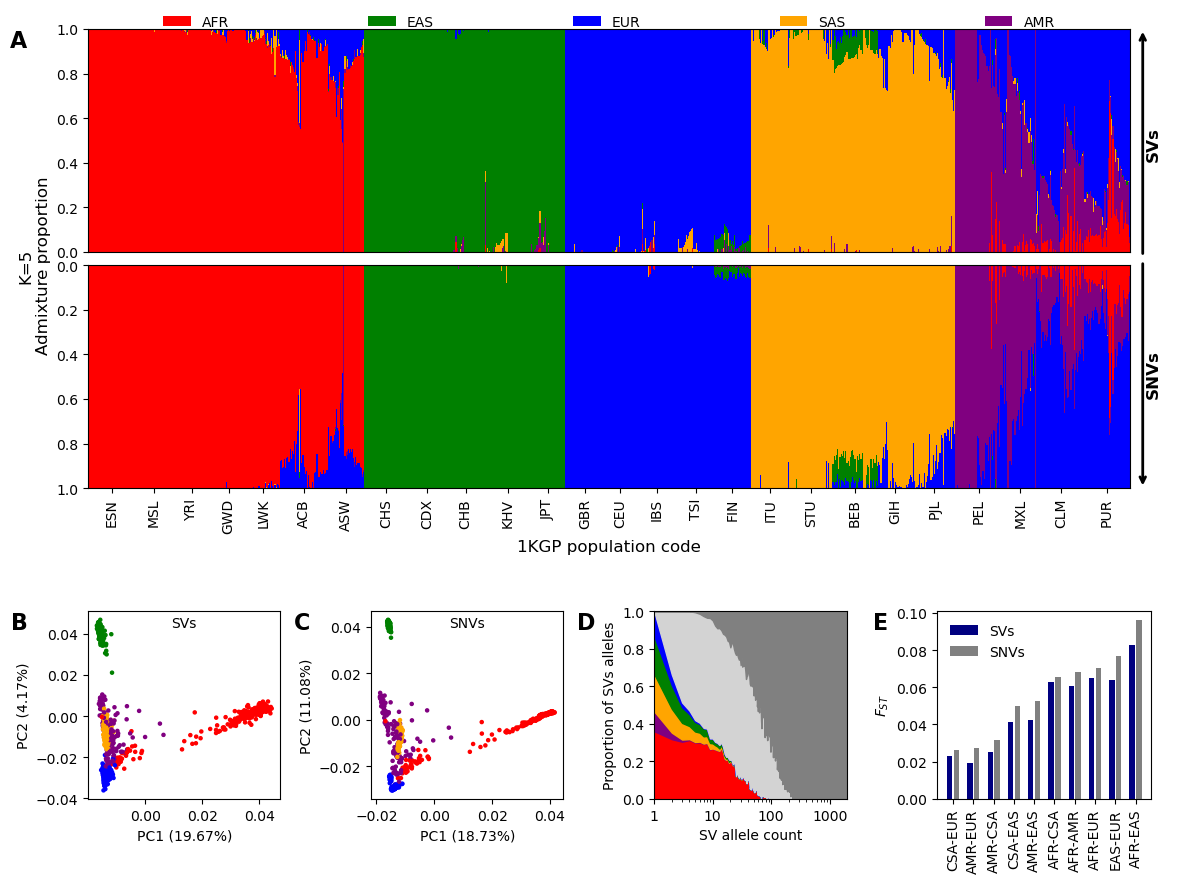

In [42]:
color_mapping = {"AFR": 'red', 'EUR': 'blue', 'CSA': 'orange', 'EAS': 'green', "AMR": 'purple'}

fig = plt.figure(figsize=(14, 10))

gs = GridSpec(20, 50, figure=fig)  # 2 rows, 3 columns

ax1 = fig.add_subplot(gs[15:, :9])
ax7 = fig.add_subplot(gs[15:, 13:22])
ax2 = fig.add_subplot(gs[15:, 26:35])
ax3 = fig.add_subplot(gs[15:, 39:49])
# cbar_ax = fig.add_subplot(gs[15:, 45])

nested_gs = GridSpecFromSubplotSpec(6, 50, subplot_spec=gs[:12, :], hspace=0.2, wspace=0)
ax4 = fig.add_subplot(nested_gs[:3, :48])
ax5 = fig.add_subplot(nested_gs[3:, :48])
ax6 = fig.add_subplot(nested_gs[:, 48:])



# ax2.legend(handles=handles, bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=3,
#              fontsize=10)

ax2.fill_between(uniq_ac, afr_specific, color=color_mapping['AFR'])
ax2.fill_between(uniq_ac, y1=afr_specific, y2=afr_specific + amr_specific, color=color_mapping['AMR'])
ax2.fill_between(uniq_ac, y1=afr_specific + amr_specific, y2=afr_specific + amr_specific + csa_specific, 
                   color=color_mapping['CSA'])
ax2.fill_between(uniq_ac, y1=afr_specific + amr_specific + csa_specific, 
                   y2=afr_specific +amr_specific + csa_specific + eas_specific, 
                   color=color_mapping['EAS'])
ax2.fill_between(uniq_ac, y1=afr_specific + amr_specific + csa_specific + eas_specific, 
                   y2=afr_specific + amr_specific + csa_specific + eas_specific + eur_specific, 
                   color=color_mapping['EUR'])


ax2.fill_between(uniq_ac, y1=afr_specific + eas_specific + eur_specific + csa_specific + amr_specific, 
                y2=afr_specific + eas_specific + eur_specific + csa_specific + amr_specific + shared, 
                color='lightgrey')
ax2.fill_between(uniq_ac, y1=afr_specific + eas_specific + eur_specific + csa_specific + amr_specific + shared, 
                y2=afr_specific + eas_specific + eur_specific + csa_specific + amr_specific + shared + shared_all, 
                color='grey')
ax2.set_xlim([1, gt_ac.max()])
ax2.set_ylim([0, 1])


ax2.set_xscale('log')
ax2.set_xticklabels([0.1, 1, 10, 100, 1000])
ax2.set_xlabel('SV allele count')
ax2.set_ylabel('Proportion of SVs alleles')

handles = [Patch(facecolor='red', label='AFR'), Patch(facecolor='purple', label='AMR'),
           Patch(facecolor='orange', label='CSA'), Patch(facecolor='green', label='EAS'),
           Patch(facecolor='blue', label='EUR'), Patch(facecolor='lightgrey', label='Shared'),
           Patch(facecolor='grey', label='Shared all')]
# ax2.legend(handles=handles, bbox_to_anchor=(0.5, -.2), loc='upper center', ncol=3)


ax1.text(-0.4, 1, 'B', transform=ax1.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax7.text(-0.4, 1, 'C', transform=ax7.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax2.text(-0.4, 1, 'D', transform=ax2.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax3.text(-0.3, 1, 'E', transform=ax3.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax4.text(-0.075, 1, 'A', transform=ax4.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

fst_vals = np.array([fst[i, j] for i in range(5) for j in range(i + 1, 5)])
fst_snvs_vals = np.array([fst_snvs[i, j] for i in range(5) for j in range(i + 1, 5)])
pop_comb = np.array([f'{populations[i]}-{populations[j]}' for i in range(5) for j in range(i + 1, 5)])

fst_vals = fst_vals[np.argsort(fst_snvs_vals)]
pop_comb = pop_comb[np.argsort(fst_snvs_vals)]
fst_snvs_vals = np.sort(fst_snvs_vals)

ax3.bar([0, 1, 3, 4, 6, 7, 9, 10, 12, 13, 15, 16, 18, 19, 21, 22, 24, 25, 27, 28], 
        np.concatenate([[fst_vals[i], fst_snvs_vals[i]] for i in range(len(fst_snvs_vals))]), 
        color=['navy', 'grey'])

ax3.set_xticks([0.5, 3.5, 6.5, 9.5, 12.5, 15.5, 18.5, 21.5, 24.5, 27.5])
ax3.set_xticklabels(pop_comb,
                   rotation=90)
ax3.set_ylabel(r'$F_{ST}$')

handles = [Patch(facecolor='navy', label='SVs'), Patch(facecolor='grey', label='SNVs')]

ax3.legend(handles=handles, loc='upper left', frameon=False)

# fst_mask = ~(np.triu(fst) > 0)
# fst_snv_mask = ~(np.tril(fst_snvs) > 0)
# diagonal = ~(np.tril(fst_snvs) == 0)

# sns.heatmap(fst, mask=fst_mask, annot=True, fmt=".2f", cmap='Blues', ax=ax3, cbar=False,
#             vmin=min([fst_snvs[~fst_snv_mask].min(), fst[~fst_mask].min()]),
#             vmax=max([fst_snvs[~fst_snv_mask].min(), fst[~fst_mask].max()]))
# sns.heatmap(fst_snvs, mask=fst_snv_mask, annot=True, fmt=".2f", cmap='Blues', ax=ax3, cbar_ax=cbar_ax,
#             vmin=min([fst_snvs[~fst_snv_mask].min(), fst[~fst_mask].min()]),
#             vmax=max([fst_snvs[~fst_snv_mask].min(), fst[~fst_mask].max()]))

# N = len(populations)
# line = ([(0, N - 1), (0, 0), (N - 1, 0)] +
#         [(N - 1 - i - j, i + 1) for i in range(N - 1) for j in (0, 1)])
# lines = [line, [(N - x, N - y) for x, y in line]]
# for l in lines:
#     # Flip y to account for invert_yaxis()
#     flipped = [(x, N - y) for x, y in l]
#     path = patches.Polygon(flipped, facecolor='none', edgecolor='black',
#                            linewidth=2, closed=True, joinstyle='round')
#     ax3.add_patch(path)
    
# ax3.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
# ax3.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
# ax3.set_xticklabels(populations)
# ax3.set_yticklabels(populations)
# ax3.invert_yaxis()
# ax3.set_xlabel("SVs", fontsize=12)
# ax3.set_title('SNVs', fontsize=12)
# cbar_ax.set_ylabel(r'$F_{st}$')


ax1.scatter(procrustes_svs[:, 0], procrustes_svs[:, 1], s=5,
            color=[color_mapping[p] for p in eigenvec_sv.superpopulation.values], marker='o')
ax1.set_xlabel(f'PC1 ({eigenval_sv.values[0][0] / eigenval_sv.values.sum() * 100:.2f}%)')
ax1.set_ylabel(f'PC2 ({eigenval_sv.values[1][0] / eigenval_sv.values.sum() * 100:.2f}%)')

ax1.text(0.5, 0.9, 'SVs', transform=ax1.transAxes, ha='center', va='bottom', )

ax7.scatter(procrustes_snvs[:, 0], procrustes_snvs[:, 1], s=5,
            color=[color_mapping[p] for p in eigenvec_snvs.superpopulation.values], marker='o')
ax7.set_xlabel(f'PC1 ({eigenval_snvs.values[0][0] / eigenval_snvs.values.sum() * 100:.2f}%)')
ax7.set_ylabel(f'PC2 ({eigenval_snvs.values[1][0] / eigenval_snvs.values.sum() * 100:.2f}%)')
ax7.text(0.5, 0.9, 'SNVs', transform=ax7.transAxes, ha='center', va='bottom')



plot_admixture_proportions(admixture_proportions, K, ax4)

handles = [Patch(facecolor='red', label='AFR'), Patch(facecolor='green', label='EAS'),
           Patch(facecolor='blue', label='EUR'), Patch(facecolor='orange', label='SAS'),
           Patch(facecolor='purple', label='AMR')]
ax4.legend(handles=handles, ncol=5, bbox_to_anchor=(0.5, 1.12), frameon=False, columnspacing=10,
           loc='upper center', draggable=True)

plot_admixture_proportions(admixture_proportions_snvs, K, ax5)
ax4.set_xlabel("")
ax4.set_ylabel("")

ax4.set_xticklabels([])
ax4.set_xticks([])

ax5.invert_yaxis()

ax5.set_ylabel("K=5\nAdmixture proportion", y=1)

ax6.set_ylim([-1, 1])
ax6.set_axis_off() 
ax6.annotate("", xy=(0.3, -1), xytext=(0.3, -0.01), arrowprops=dict(arrowstyle="->", lw=2))
ax6.annotate("", xy=(0.3, 1), xytext=(0.3, 0.01), arrowprops=dict(arrowstyle="->", lw=2))
ax6.text(0.55, 0.5, "SVs", rotation=90, fontweight='bold', ha='center', va='center', fontsize=12)
ax6.text(0.55, -0.5, "SNVs", rotation=90, fontweight='bold', ha='center', va='center', fontsize=12)
fig.savefig('population_structure.pdf', dpi=600, bbox_inches='tight')

In [37]:
fst_vals, fst_snvs_vals

(array([0.01952684, 0.02323394, 0.02497222, 0.04119722, 0.0425375 ,
        0.06070664, 0.06269623, 0.06401014, 0.06496324, 0.08272663]),
 array([0.01952684, 0.02323394, 0.02497222, 0.04119722, 0.0425375 ,
        0.06070664, 0.06269623, 0.06401014, 0.06496324, 0.08272663]))

## Analyze genome-wide distribution of SVs

In [24]:
giggles_gt = giggles_calls["call_genotype"]
sv_affected_per_genome = np.zeros(giggles_gt.shape[1])
for v, vsize in tqdm.tqdm(zip(giggles_gt, variant_sizes), total=giggles_gt.shape[0]):
    v = np.where(v < 0, np.nan, v)
    v = np.nansum(v, axis=1)
    sv_affected_per_genome[v > 0] += vsize

smallvar_affected_per_genome = []
for chrom in np.arange(1, 23):
    smallvar_affected_per_genome.append(np.load(f'{base_dir}1kgp_high_coverage_hg38/1kGP_high_coverage_Illumina.chr{chrom}.filtered.sequence_affected_by_smvar.npz')['arr_0'])
smallvar_affected_per_genome = np.vstack(smallvar_affected_per_genome).sum(axis=0)



100%|██████████| 167346/167346 [08:19<00:00, 334.76it/s]


/tmp/ipykernel_1082631/3649991075.py:224: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


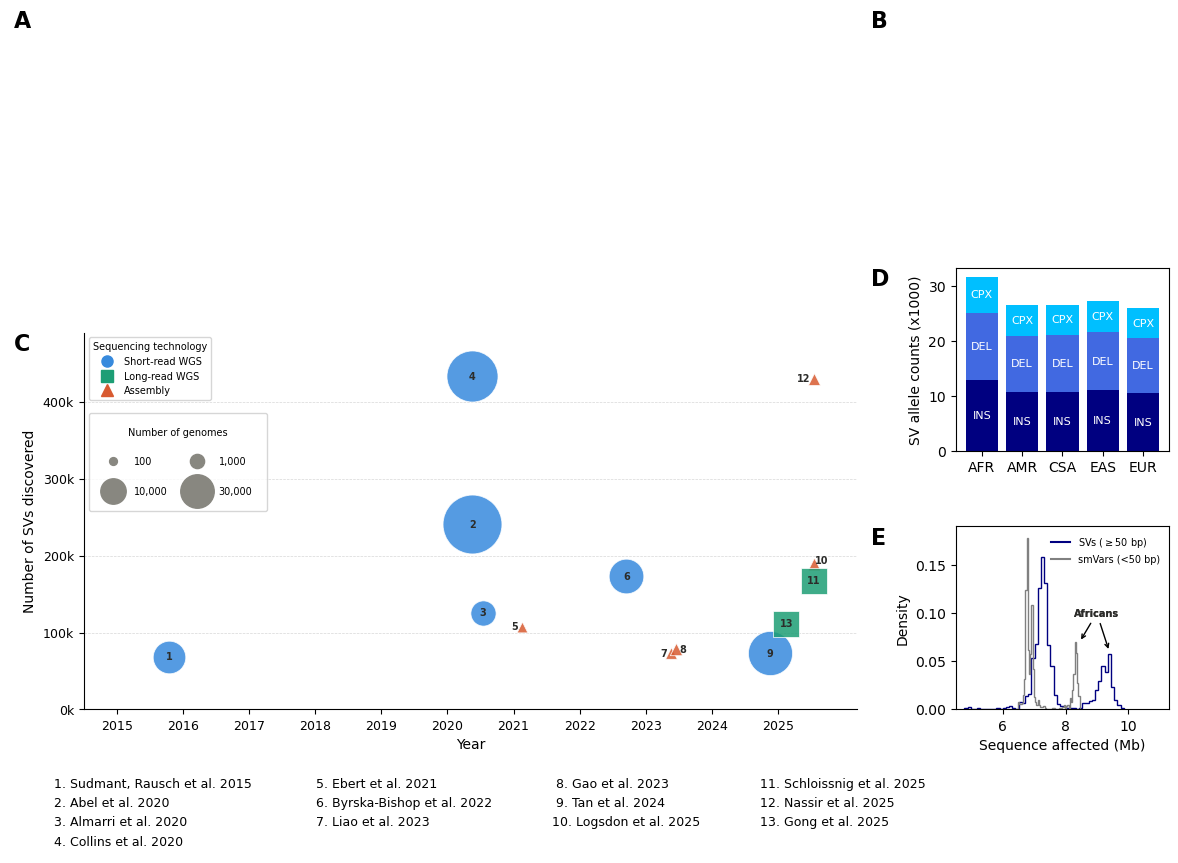

Done


In [26]:
number_of_svs = [68818, 99604, 241031, 126018, 433371, 107590, 173366, 73000, 78072, 73035, 188500, 167291,
                 429982, 111288]
number_of_genomes = [2504, 15, 26347, 911, 14891, 35, 3202, 47, 58, 8392, 65, 1019, 53, 945]
year = [2015, 2019 2020, 2020, 2020, 2021, 2022, 2023, 2023, 2024, 2025, 2025, 2025, 2025]
month = ['Oct', 'Jan', 'May', 'Jul', 'May', 'Feb', 'Sep', 'May', 'Jun', 'Nov', 'Jul', 'Jul', 'Jul', 'Feb']
technology = ['srWGS', 'lrWGS', 'srWGS', 'srWGS', 'srWGS', 'Assembly', 'srWGS',
              'Assembly', 'Assembly', 'srWGS', 'Assembly', 'lrWGS', 'Assembly', 'lrWGS']
publication = ['Sudmant, Rausch et al.', 'Audano et al.', 'Abel et al.', 'Almarri et al.', 'Collins et al.',
               'Ebert et al.', 'Byrska-Bishop et al.', 'Liao et al.', 'Gao et al.', 'Tan et al.',
               'Logsdon et al.', 'Schloissnig et al.', 'Nassir et al.', 'Gong et al.']

month_map = {'Jan': 0, 'Feb': 1, 'Mar': 2, 'Apr': 3, 'May': 4, 'Jun': 5,
             'Jul': 6, 'Aug': 7, 'Sep': 8, 'Oct': 9, 'Nov': 10, 'Dec': 11}

# Convert year + month to decimal year
decimal_year = [y + (month_map[m] + 0.5) / 12
                for y, m in zip(year, month)]

tech_styles = {
    'srWGS':    {'marker': 'o', 'color': '#378ADD', 'label': 'Short-read WGS'},
    'lrWGS':    {'marker': 's', 'color': '#1D9E75', 'label': 'Long-read WGS'},
    'Assembly': {'marker': '^', 'color': '#D85A30', 'label': 'Assembly'},
}

genome_arr = np.array(number_of_genomes)
size_min, size_max = 60, 1800
sizes = size_min + (np.sqrt(genome_arr) - np.sqrt(genome_arr.min())) / \
        (np.sqrt(genome_arr.max()) - np.sqrt(genome_arr.min())) * (size_max - size_min)

fig = plt.figure(figsize=(14, 14))


gs = GridSpec(11, 35, figure=fig)  # 2 rows, 3 columns

ax1 = fig.add_subplot(gs[:4, :25])

ax5 = fig.add_subplot(gs[:3, 28:])

ax2 = fig.add_subplot(gs[4:7, 28:])
ax3 = fig.add_subplot(gs[5:, :25])
ax4 = fig.add_subplot(gs[8:, 28:])


ax1.set_axis_off() 
ax5.set_axis_off() 


bars = ax2.bar([0, 1, 2, 3, 4], [ins_afr / 1000, ins_amr / 1000, ins_csa / 1000, ins_eas / 1000, ins_eur / 1000],
                 color='navy')
ax2.bar_label(bars, labels=['INS'] * 5, label_type='center', color='white', fontsize=8)
bars = ax2.bar([0, 1, 2, 3, 4], [del_afr / 1000, del_amr / 1000, del_csa / 1000, del_eas / 1000, del_eur / 1000], 
       bottom=[ins_afr / 1000, ins_amr / 1000, ins_csa / 1000, ins_eas / 1000, ins_eur / 1000], color='royalblue')
ax2.bar_label(bars, labels=['DEL'] * 5, label_type='center', color='white', fontsize=8)

bars = ax2.bar([0, 1, 2, 3, 4], [cpx_afr / 1000, cpx_amr  / 1000, cpx_csa  / 1000, cpx_eas  / 1000, cpx_eur  / 1000], 
       bottom=[(ins_afr + del_afr) / 1000, (ins_amr + del_amr) / 1000, (ins_csa + del_csa) / 1000, 
               (ins_eas + del_eas) / 1000, (ins_eur + del_eur)  / 1000], 
       color='deepskyblue')
ax2.bar_label(bars, labels=['CPX'] * 5, label_type='center', color='white', fontsize=8)

ax2.set_xticks([0, 1, 2, 3, 4])
ax2.set_xticklabels(['AFR', 'AMR', 'CSA', 'EAS', 'EUR'], fontsize=10)
ax2.set_ylabel('SV allele counts (x1000)', fontsize=10)


ax4.hist(sv_affected_per_genome / 1e6, bins=50, histtype='step', color='navy', 
        weights=np.repeat(1 / sv_affected_per_genome.shape[0], sv_affected_per_genome.shape[0]))
ax4.hist(smallvar_affected_per_genome / 1e6, bins=50, histtype='step', color='grey', 
        weights=np.repeat(1 / smallvar_affected_per_genome.shape[0], smallvar_affected_per_genome.shape[0]))
ax4.set_xlabel('Sequence affected (Mb)', fontsize=10)
ax4.set_ylabel("Density", fontsize=10)

handles = [Line2D([0], [0], color='navy', label=r'SVs ($\geq$50 bp)'),
           Line2D([0], [0], color='grey', label='smVars (<50 bp)')]
ax4.legend(handles=handles, frameon=False, fontsize=7, loc='upper right')
ax4.annotate('Africans',
             xy=(8.45, 0.07),
             xytext=(9, 0.1),
             textcoords='data',
             fontsize=7,
             color='#2C2C2A',
             fontweight='bold',
             va='center', ha='center',
             arrowprops=dict(arrowstyle="->"))
ax4.annotate('Africans',
             xy=(9.4, 0.06),
             xytext=(9, 0.1),
             textcoords='data',
             fontsize=7,
             color='#2C2C2A',
             fontweight='bold',
             va='center', ha='center',
             arrowprops=dict(arrowstyle="->"))
ax4.set_ylim([0, 0.19])
ax4.set_xlim([4.5, 11.3])

# ax4.arrow(9, 0.09, -0.55, -0.02, zorder=999)
# ax4.arrow(9, 0.09, 0.4, -0.025,  head_width=0.0075, head_length=0.08, fc='k', ec='k', shape='full')



for i, (dx, svs, pub, tech, sz) in enumerate(
        zip(decimal_year, number_of_svs, publication, technology, sizes)):
    style = tech_styles[tech]
    ax3.scatter(dx, svs, s=sz,
               marker=style['marker'],
               color=style['color'],
               alpha=0.85,
               edgecolors='white',
               linewidths=0.6,
               zorder=3)
    # Small index number next to each point
    if i == 4 or i == 6:
        ax3.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(-5, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 7:
        ax3.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 9:
        ax3.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(6, 3),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 11:
        ax3.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(-7, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')

    else:
        ax3.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(0, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')

# ── Technology legend ───────────────────────────────────────────────────────
tech_handles = [
    mlines.Line2D([], [], color=v['color'], marker=v['marker'],
                  linestyle='None', markersize=8, label=v['label'])
    for v in tech_styles.values()
]

# ── Sample size legend ──────────────────────────────────────────────────────
ref_genomes = [100, 1000, 10000, 30000]
ref_sizes = size_min + (np.sqrt(ref_genomes) - np.sqrt(genome_arr.min())) / \
            (np.sqrt(genome_arr.max()) - np.sqrt(genome_arr.min())) * (size_max - size_min)
size_handles = [
    mlines.Line2D([], [], color='#888780', marker='o', linestyle='None',
                  markersize=np.sqrt(s) * 0.55,
                  label=f'{n:,}')
    for n, s in zip(ref_genomes, ref_sizes)
]

leg1 = ax3.legend(handles=tech_handles, title='Sequencing technology',
                 loc='upper left', frameon=True, fontsize=7, title_fontsize=7)
leg2 = ax3.legend(handles=[size_handles[0], size_handles[2], size_handles[1], size_handles[3]], 
                  title='Number of genomes', ncol=2, handletextpad=1.2,
                 loc='upper left', frameon=True, fontsize=7, title_fontsize=7,
                 labelspacing=2, borderpad=1.5, bbox_to_anchor=(0.0, 0.8))
ax3.add_artist(leg1)
ax3.add_artist(leg2)


ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Number of SVs discovered', fontsize=10)

ax3.set_xlim(2014.5, 2026.2)
ax3.set_ylim(0, 490000)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax3.set_xticks(range(2015, 2026))
ax3.tick_params(axis='both', labelsize=9)
ax3.spines[['top', 'right']].set_visible(False)
ax3.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
ax3.set_axisbelow(True)

# ── Numbered publication key below the plot ─────────────────────────────────
key_lines = []
for i, (pub, year) in enumerate(zip(publication, year)):
    key_lines.append(Line2D([], [], ls='', label=f'{i+1:>2}. {pub} {year}'))

leg3 = ax3.legend(handles=key_lines,
                 loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=9, ncol=4)


ax1.text(-0.09, 1, 'A', transform=ax1.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax2.text(-0.4, 1, 'D', transform=ax2.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax3.text(-0.09, 1, 'C', transform=ax3.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax4.text(-0.4, 1, 'E', transform=ax4.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

ax5.text(-0.4, 1, 'B', transform=ax5.transAxes,
           fontsize=16, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.subplots_adjust(bottom=0.38)
plt.savefig('sv_discovery.pdf', dpi=300, bbox_inches='tight')
plt.savefig('sv_discovery.png', dpi=300, bbox_inches='tight')
plt.show()
print("Done")

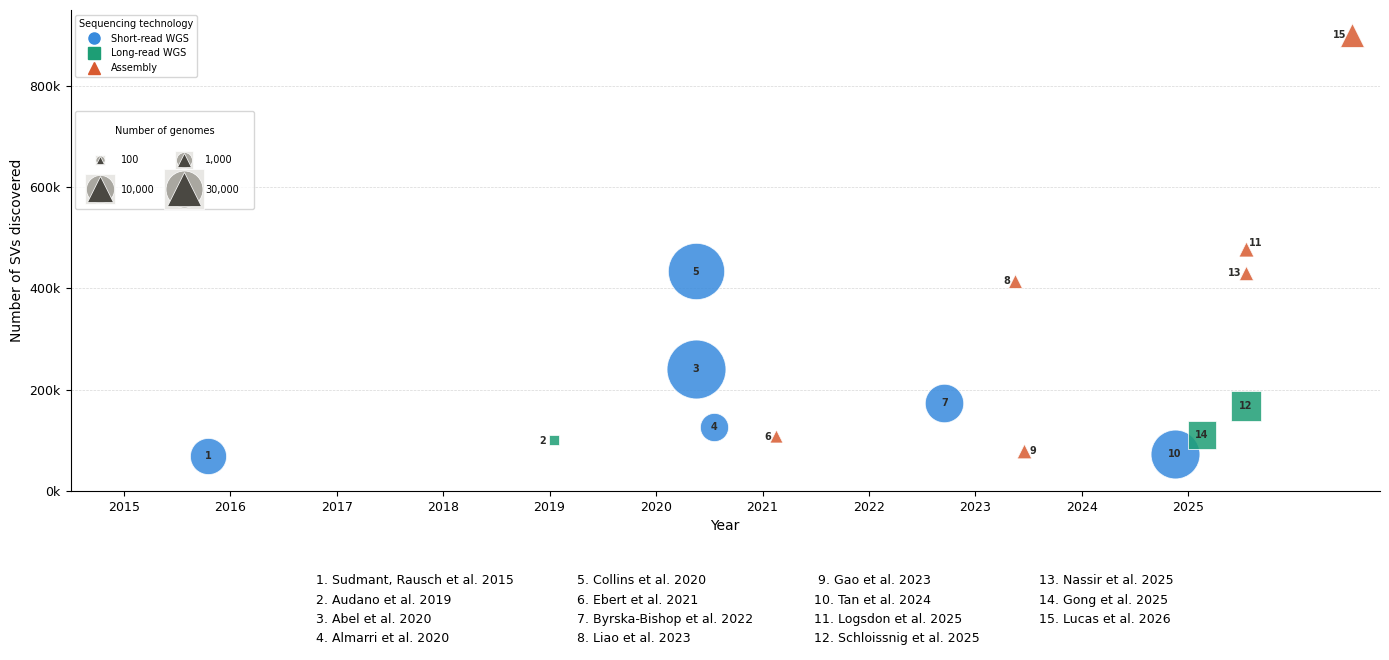

Done


In [56]:
import matplotlib as mpl
from matplotlib.legend_handler import HandlerTuple
mpl.rcParams['pdf.fonttype'] = 42


number_of_svs = [68818, 99604, 241031, 126018, 433371, 107590, 173366, 413809, 78072, 73035, 478587, 167291,
                 429982, 111288, 901029]
number_of_genomes = [2504, 15, 17795, 911, 14891, 35, 3202, 47, 58, 8392, 65, 1019, 53, 945, 460]
year = [2015, 2019, 2020, 2020, 2020, 2021, 2022, 2023, 2023, 2024, 2025, 2025, 2025, 2025, 2026]
month = ['Oct', 'Jan', 'May', 'Jul', 'May', 'Feb', 'Sep', 'May', 'Jun', 'Nov', 'Jul', 'Jul', 'Jul', 'Feb', 
         'Jul']
technology = ['srWGS', 'lrWGS', 'srWGS', 'srWGS', 'srWGS', 'Assembly', 'srWGS',
              'Assembly', 'Assembly', 'srWGS', 'Assembly', 'lrWGS', 'Assembly', 'lrWGS', 'Assembly']
publication = ['Sudmant, Rausch et al.', 'Audano et al.', 'Abel et al.', 'Almarri et al.', 'Collins et al.',
               'Ebert et al.', 'Byrska-Bishop et al.', 'Liao et al.', 'Gao et al.', 'Tan et al.',
               'Logsdon et al.', 'Schloissnig et al.', 'Nassir et al.', 'Gong et al.', 'Lucas et al.']

month_map = {'Jan': 0, 'Feb': 1, 'Mar': 2, 'Apr': 3, 'May': 4, 'Jun': 5,
             'Jul': 6, 'Aug': 7, 'Sep': 8, 'Oct': 9, 'Nov': 10, 'Dec': 11}

# Convert year + month to decimal year
decimal_year = [y + (month_map[m] + 0.5) / 12
                for y, m in zip(year, month)]

tech_styles = {
    'srWGS':    {'marker': 'o', 'color': '#378ADD', 'label': 'Short-read WGS'},
    'lrWGS':    {'marker': 's', 'color': '#1D9E75', 'label': 'Long-read WGS'},
    'Assembly': {'marker': '^', 'color': '#D85A30', 'label': 'Assembly'},
}

genome_arr = np.array(number_of_genomes)
size_min, size_max = 60, 1800
sizes = size_min + (np.sqrt(genome_arr) - np.sqrt(genome_arr.min())) / \
        (np.sqrt(genome_arr.max()) - np.sqrt(genome_arr.min())) * (size_max - size_min)

fig, ax = plt.subplots(figsize=(14, 8))


for i, (dx, svs, pub, tech, sz) in enumerate(
        zip(decimal_year, number_of_svs, publication, technology, sizes)):
    style = tech_styles[tech]
    ax.scatter(dx, svs, s=sz,
               marker=style['marker'],
               color=style['color'],
               alpha=0.85,
               edgecolors='white',
               linewidths=0.6,
               zorder=3)
    # Small index number next to each point
    if i == 5 or i == 7:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(-6, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 8:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(6, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 10:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(7, 4),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 12 or i == 1:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(-8, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')
    elif i == 14:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(-9, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')

    else:
        ax.annotate(str(i + 1),
                    xy=(dx, svs),
                    xytext=(0, 0),
                    textcoords='offset points',
                    fontsize=7,
                    color='#2C2C2A',
                    fontweight='bold',
                    va='center', ha='center')

# ── Technology legend ───────────────────────────────────────────────────────
tech_handles = [
    mlines.Line2D([], [], color=v['color'], marker=v['marker'],
                  linestyle='None', markersize=8, label=v['label'])
    for v in tech_styles.values()
]

# ── Sample size legend ──────────────────────────────────────────────────────
ref_genomes = [100, 1000, 10000, 30000]
ref_sizes = size_min + (np.sqrt(ref_genomes) - np.sqrt(genome_arr.min())) / \
            (np.sqrt(genome_arr.max()) - np.sqrt(genome_arr.min())) * (size_max - size_min)

size_shades = {'s': '#E8E7E4', 'o': '#A9A7A0', '^': '#4A4842'}  # light → dark

size_handles = [
    tuple(
        mlines.Line2D([], [], color=size_shades[m], marker=m,
                      linestyle='None', markersize=np.sqrt(s) * scaling,
                      markeredgecolor='white', markeredgewidth=0.5)
        for m, scaling in zip(('s', 'o', '^'), [0.6, 0.55, 0.5])          # draw order = z-order
    )
    for s in ref_sizes
]

# size_handles = [
#     mlines.Line2D([], [], color='#888780', marker='o', linestyle='None',
#                   markersize=np.sqrt(s) * 0.55,
#                   label=f'{n:,}')
#     for n, s in zip(ref_genomes, ref_sizes)
# ]

leg1 = ax.legend(handles=tech_handles, title='Sequencing technology',
                 loc='upper left', frameon=True, fontsize=7, title_fontsize=7)
leg2 = ax.legend(
    handles=[size_handles[0], size_handles[2], size_handles[1], size_handles[3]],
    labels=[f'{n:,}' for n in [100, 10000, 1000, 30000]],
    title='Number of genomes', ncol=2, handletextpad=1.2,
    loc='upper left', frameon=True, fontsize=7, title_fontsize=7,
    labelspacing=2, borderpad=1.5, bbox_to_anchor=(0.0, 0.8),
    handler_map={tuple: HandlerTuple(ndivide=1, pad=0.0)},
)
ax.add_artist(leg1)
ax.add_artist(leg2)


ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Number of SVs discovered', fontsize=10)

ax.set_xlim(2014.5, 2026.8)
ax.set_ylim(0, 950000)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax.set_xticks(range(2015, 2026))
ax.tick_params(axis='both', labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# ── Numbered publication key below the plot ─────────────────────────────────
key_lines = []
for i, (pub, year) in enumerate(zip(publication, year)):
    key_lines.append(Line2D([], [], ls='', label=f'{i+1:>2}. {pub} {year}'))

leg3 = ax.legend(handles=key_lines,
                 loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=9, ncol=4)


plt.tight_layout()
plt.subplots_adjust(bottom=0.38)
plt.savefig('sv_studies.pdf', dpi=600, bbox_inches='tight')
plt.show()
print("Done")

Loading SD annotations...
  Loaded 53,608 SDs -> 6,212 merged intervals
No contig name field found, using sorted fallback:
['chr1' 'chr10' 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17'
 'chr18' 'chr19' 'chr2' 'chr20' 'chr21' 'chr22' 'chr3' 'chr4' 'chr5'
 'chr6' 'chr7' 'chr8' 'chr9']

Unique contigs in data: ['chr1' 'chr10' 'chr11' 'chr12' 'chr13' 'chr14' 'chr15' 'chr16' 'chr17'
 'chr18' 'chr19' 'chr2' 'chr20' 'chr21' 'chr22' 'chr3' 'chr4' 'chr5'
 'chr6' 'chr7' 'chr8' 'chr9']
Global max density: 303 SVs per 500kb bin


/tmp/ipykernel_2377268/2829693846.py:286: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.0, 0.97, 1])


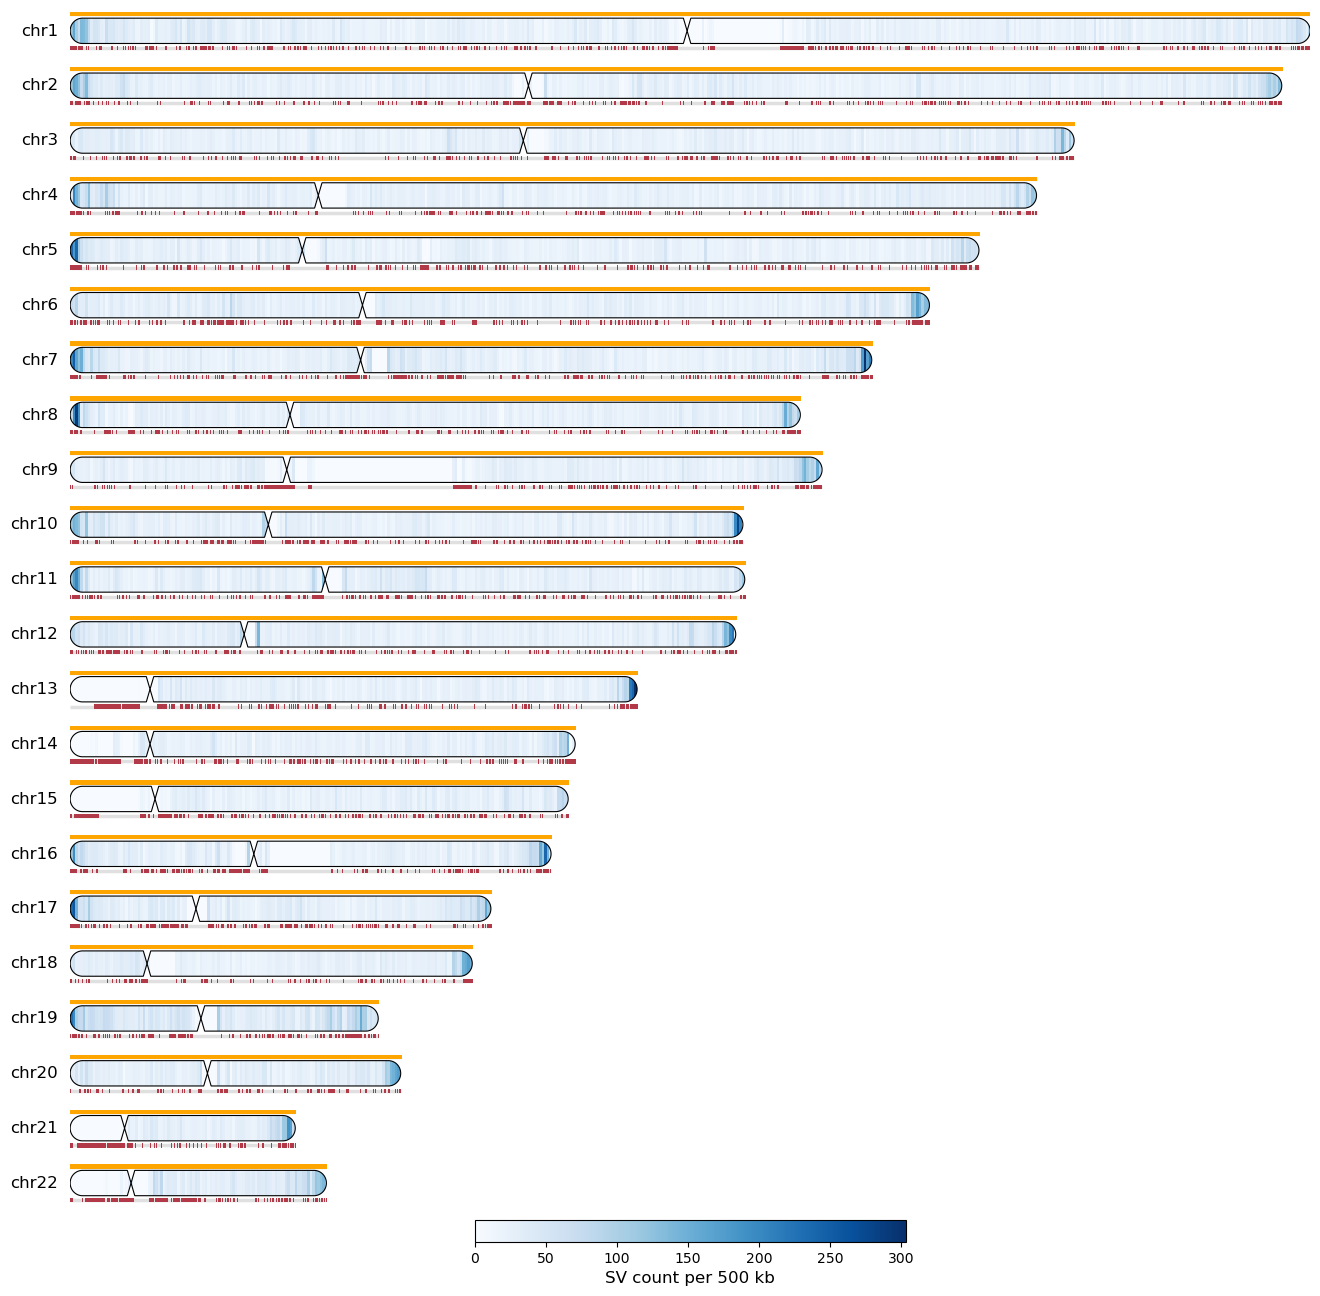

In [9]:
def load_annotation(filepath, chrom_col=0, start_col=1, end_col=2, 
                    skiprows=0, comment='#', header=None):
    """Load a BED-like annotation file and return a DataFrame."""
    df = pd.read_csv(filepath, sep='\t', header=header, comment=comment,
                     usecols=[chrom_col, start_col, end_col])
    df.columns = ['chrom', 'start', 'end']
    df = df[df['chrom'].isin(chromosomes)]
    df = df.drop_duplicates(subset=['chrom', 'start', 'end'])
    return df

def merge_intervals(starts, ends):
    """Merge overlapping intervals, return merged starts and ends."""
    if len(starts) == 0:
        return starts, ends
    order = np.argsort(starts)
    starts, ends = starts[order], ends[order]
    merged_starts, merged_ends = [starts[0]], [ends[0]]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= merged_ends[-1]:
            merged_ends[-1] = max(merged_ends[-1], e)
        else:
            merged_starts.append(s)
            merged_ends.append(e)
    return np.array(merged_starts), np.array(merged_ends)


def merge_intervals_df(df):
    """Merge overlapping intervals per chromosome, return merged DataFrame."""
    merged = []
    for chrom, group in df.groupby('chrom'):
        starts, ends = merge_intervals(group['start'].values, group['end'].values)
        for s, e in zip(starts, ends):
            merged.append({'chrom': chrom, 'start': s, 'end': e})
    return pd.DataFrame(merged)

chromosomes = [f'chr{i}' for i in list(range(1, 23))]
print("Loading SD annotations...")
sd_raw = load_annotation(
    f'{base_dir}1KGP_ONT_VIENNA/reference/chm13v2.0_SD.full.bed',
    skiprows=1, header=0
)
sd_merged = merge_intervals_df(sd_raw)
print(f"  Loaded {len(sd_raw):,} SDs -> {len(sd_merged):,} merged intervals")


sample_info = pd.read_csv(f'{base_dir}1KGP_ONT_VIENNA/sample_info.tab', sep='\t',
                          names=['IID', 'population', 'superpopulation', 'sex'])

# giggles_calls = zarr.open_group(f'{base_dir}HGSVC3/pangenie_chm13_all_decomposed_lenient.vcz/')
giggles_calls = zarr.open_group(f'{base_dir}1KGP_ONT_VIENNA/giggles-genotyping_final-vcf.unphased.vcz/')
sample_ids = giggles_calls['sample_id'][:]
sample_ids = pd.DataFrame(sample_ids).set_index(0).join(sample_info.set_index('IID'))
variant_ids = giggles_calls['variant_id'][:]
variant_types = np.array([vid.split('-')[2] for vid in variant_ids])
variant_sizes = np.array([int(vid.split('-')[4]) for vid in variant_ids])
variant_ids = np.array(['-'.join(v.split('-')[:3]) + f"-{v.split('-')[4]}" for v in variant_ids])

# --- Contig mapping: print and verify before plotting ---
contigs = giggles_calls['variant_contig'][:]
positions = giggles_calls['variant_position'][:]
variant_types = np.array([vid.split('-')[2] for vid in variant_ids])

variant_types = variant_types[contigs < 22]
positions = positions[contigs < 22]
variant_sizes = variant_sizes[contigs < 22]
contigs = contigs[contigs < 22]

positions = positions[variant_types != 'SNV']
contigs = contigs[variant_types != 'SNV']
variant_sizes = variant_sizes[variant_types != 'SNV']
variant_types = variant_types[variant_types != 'SNV']

positions = positions[variant_sizes >= 50]
contigs = contigs[variant_sizes >= 50]
variant_types = variant_types[variant_sizes >= 50]
variant_sizes = variant_sizes[variant_sizes >= 50]

# CHM13T2T chromosome lengths
chm13_lengths = {
    'chr1': 248387328, 'chr2': 242696752, 'chr3': 201105948, 'chr4': 193574945,
    'chr5': 182045439, 'chr6': 172126628, 'chr7': 160567428, 'chr8': 146259331,
    'chr9': 150617247, 'chr10': 134758134, 'chr11': 135127769, 'chr12': 133324548,
    'chr13': 113566686, 'chr14': 101161492, 'chr15': 99753195, 'chr16': 96330374,
    'chr17': 84276897, 'chr18': 80542538, 'chr19': 61707364, 'chr20': 66210255,
    'chr21': 45090682, 'chr22': 51324926, 'chrX': 154259566, 'chrY': 62460029
}

chm13_centromeres = {
    'chr1': 123584058, 'chr2': 91797242, 'chr3': 90772459, 'chr4': 49708101,
    'chr5': 46485901, 'chr6': 58553889, 'chr7': 58169775, 'chr8': 44033744,
    'chr9': 43389635, 'chr10': 39686683, 'chr11': 51090023, 'chr12': 34856694,
    'chr13': 16000000, 'chr14': 16000000, 'chr15': 17000000, 'chr16': 36800000,
    'chr17': 25200000, 'chr18': 15400000, 'chr19': 26200000, 'chr20': 27500000,
    'chr21': 10900000, 'chr22': 12200000, 'chrX': 60600000, 'chrY': 10300000
}



# Find contig name field — try common names
contig_names = None
for key in ['contigs', 'contig_names', 'chromosomes', 'chrom_names']:
    if key in giggles_calls:
        raw = giggles_calls[key][:]
        contig_names = np.array([c.decode() if isinstance(c, bytes) else c for c in raw])
        print(f"Found contig names under '{key}':")
        print(contig_names)
        break

if contig_names is None:
    # Fall back: assume sorted order chr1, chr10, chr11...
#     chromosomes_sorted = sorted([f'chr{i}' for i in list(range(1, 23)) + ['X', 'Y']])
    chromosomes_sorted = sorted([f'chr{i}' for i in list(range(1, 23))])
    contig_names = np.array(chromosomes_sorted)
    print("No contig name field found, using sorted fallback:")
    print(contig_names)

# Map integer indices to chromosome names
contig_name_per_variant = contig_names[contigs]
print("\nUnique contigs in data:", np.unique(contig_name_per_variant))

# chromosomes = [f'chr{i}' for i in list(range(1, 23)) + ['X', 'Y']]
chromosomes = [f'chr{i}' for i in list(range(1, 23))]
max_len = max(chm13_lengths.values())
bin_size = 500_000
density_cmap = plt.cm.Blues


def draw_chromosome(ax, chrom_len, centromere_pos, max_len, color='lightgrey'):
    scaled_len = chrom_len / max_len
    scaled_cen = centromere_pos / max_len
    y_top = 0.8
    y_bot = 0.2
    y_mid = 0.5
    height = y_top - y_bot
    r = min(height / 2 * (1 / (max_len / chrom_len)) * 0.5, 0.01)
    notch_width = 0.003
    y_top_notch = y_mid
    y_bot_notch = y_mid
    n_cap = 75
    verts = []

    for i in range(n_cap + 1):
        angle = np.pi + (np.pi / 2) * (i / n_cap)
        verts.append((r + r * np.cos(angle), y_mid + (height / 2) * np.sin(angle)))

    verts.append((scaled_cen - notch_width, y_bot))
    verts.append((scaled_cen, y_bot_notch))
    verts.append((scaled_cen + notch_width, y_bot))
    verts.append((scaled_len - r, y_bot))

    for i in range(n_cap + 1):
        angle = -np.pi / 2 + (np.pi / 2) * (i / n_cap)
        verts.append((scaled_len - r + r * np.cos(angle), y_mid + (height / 2) * np.sin(angle)))
    for i in range(n_cap + 1):
        angle = (np.pi / 2) * (i / n_cap)
        verts.append((scaled_len - r + r * np.cos(angle), y_mid + (height / 2) * np.sin(angle)))

    verts.append((scaled_len - r, y_top))
    verts.append((scaled_cen + notch_width, y_top))
    verts.append((scaled_cen, y_top_notch))
    verts.append((scaled_cen - notch_width, y_top))
    verts.append((r, y_top))

    for i in range(n_cap + 1):
        angle = np.pi / 2 + (np.pi / 2) * (i / n_cap)
        verts.append((r + r * np.cos(angle), y_mid + (height / 2) * np.sin(angle)))

    verts = np.array(verts)
    chrom_patch = patches.Polygon(
        verts, closed=True,
        facecolor=color, edgecolor='none', linewidth=0.8, zorder=2
    )
    ax.add_patch(chrom_patch)
    return chrom_patch, scaled_len, verts


# Global max density
global_max_density = 0
for chrom in chromosomes:
    chrom_len = chm13_lengths.get(chrom)
    chrom_mask = contig_name_per_variant == chrom
    chrom_positions = positions[chrom_mask]
    if len(chrom_positions) == 0:
        continue
    bins = np.arange(0, chrom_len + bin_size, bin_size)
    counts, _ = np.histogram(chrom_positions, bins=bins)
    global_max_density = max(global_max_density, counts.max())

print(f"Global max density: {global_max_density} SVs per 500kb bin")

n_rows = len(chromosomes)
fig, axes = plt.subplots(n_rows, 1, figsize=(16, 16),
                         gridspec_kw={'hspace': 0.3})

for idx, chrom in enumerate(chromosomes):
    ax = axes[idx]
    chrom_len = chm13_lengths.get(chrom)
    cen_pos = chm13_centromeres.get(chrom)
    if chrom_len is None:
        ax.axis('off')
        continue

    chrom_patch, scaled_len, verts = draw_chromosome(ax, chrom_len, cen_pos, max_len)

    # Chromosome label
    ax.text(-0.01, 0.5, chrom, transform=ax.transAxes,
            fontsize=12, va='center', ha='right')

    # Density bins
    chrom_mask = contig_name_per_variant == chrom
    chrom_positions = positions[chrom_mask]
    bins = np.arange(0, chrom_len + bin_size, bin_size)
    counts, edges = np.histogram(chrom_positions, bins=bins)

    # Build clip path from chromosome vertices
    from matplotlib.path import Path
    closed_verts = np.vstack([verts, verts[0]])
    chrom_path = Path(closed_verts)
    clip_patch = patches.PathPatch(chrom_path, transform=ax.transData, visible=False)
    ax.add_patch(clip_patch)

    for i, count in enumerate(counts):
        bin_start = edges[i] / max_len
        bin_end = edges[i + 1] / max_len
        norm_density = count / global_max_density
        fc = density_cmap(norm_density)
        rect = patches.Rectangle(
            (bin_start, 0.2), bin_end - bin_start, 0.6,
            facecolor=fc, edgecolor='none', zorder=3,
            transform=ax.transData
        )
        ax.add_patch(rect)
        rect.set_clip_path(clip_patch)

    # Outline on top
    outline = patches.Polygon(
        verts, closed=True,
        facecolor='none', edgecolor='black', linewidth=0.8, zorder=4
    )
    ax.add_patch(outline)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.yaxis.label.set_visible(True)
    
    sd_track_top, sd_track_bot = 0.14, 0.04   # below the ideogram (which spans 0.2–0.8)

    sd_chrom = sd_merged[sd_merged['chrom'] == chrom]
    if len(sd_chrom):
        s, e = merge_intervals(sd_chrom['start'].values, sd_chrom['end'].values)
        ax.hlines(sd_track_bot + (sd_track_top - sd_track_bot) / 2,
                  0, chrom_len / max_len,
                  color='0.88', linewidth=2.5, zorder=1)
        for si, ei in zip(s, e):
            ax.add_patch(patches.Rectangle(
                (si / max_len, sd_track_bot),
                max((ei - si) / max_len, 0.0008),   # floor so small SDs stay visible
                sd_track_top - sd_track_bot,
                facecolor='#B23A48', edgecolor='none', zorder=2))
            
        sd_track_top, sd_track_bot = 0.14, 0.04   # below the ideogram (which spans 0.2–0.8)

sm = plt.cm.ScalarMappable(cmap=density_cmap,
                            norm=plt.Normalize(vmin=0, vmax=global_max_density))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                    fraction=0.0175, pad=0.013, shrink=1)
cbar.set_label('SV count per 500 kb', fontsize=12)

plt.tight_layout(rect=[0, 0.0, 0.97, 1])
fig.savefig('sv_karyogram.pdf', bbox_inches='tight', dpi=600)
plt.show()

Loading repeat annotations...
  Loaded 5,234,469 repeats -> 3,874,072 merged intervals
Loading SD annotations...
  Loaded 53,608 SDs -> 6,212 merged intervals

Testing enrichment in Repeats...


100%|██████████| 10000/10000 [03:16<00:00, 50.87it/s]


  COMPLEX   : n= 25372, obs=0.708, exp=0.635, fold=1.12, z=25.32, p=0.0000


100%|██████████| 10000/10000 [04:45<00:00, 35.01it/s]


  DEL       : n= 65720, obs=0.671, exp=0.637, fold=1.05, z=18.80, p=0.0000


...

  COMPLEX   : n= 25372, obs=0.090, exp=0.066, fold=1.36, z=15.41, p=0.0000


100%|██████████| 10000/10000 [01:07<00:00, 148.42it/s]


  DEL       : n= 65720, obs=0.074, exp=0.066, fold=1.13, z=8.81, p=0.0000


100%|██████████| 10000/10000 [01:16<00:00, 131.33it/s]


  INS       : n= 74705, obs=0.058, exp=0.066, fold=0.88, z=-8.45, p=1.0000


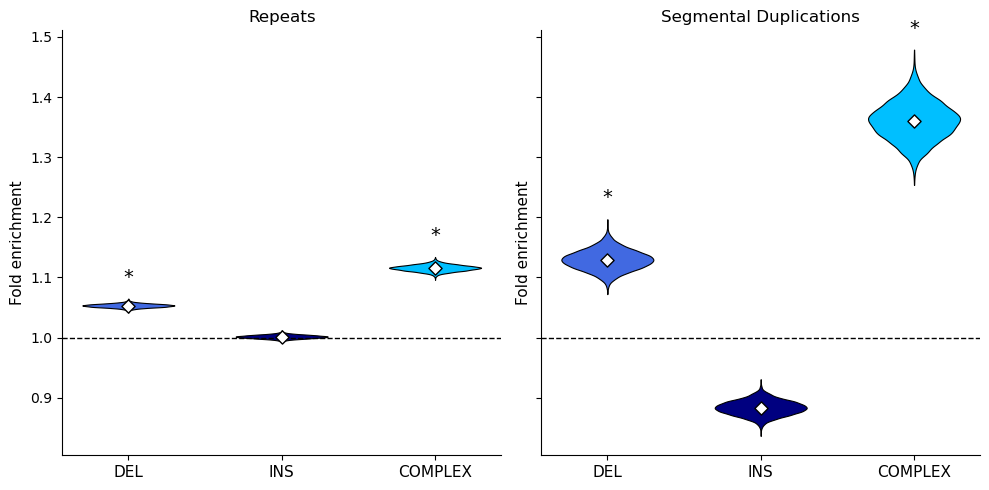

            Annotation SV_type  N_SVs  observed  expected  fold_enrichment   z_score  p_value  p_value_bonferroni  significant
               Repeats COMPLEX  25372  0.708498  0.634951         1.115830 25.321961   0.0000                 0.0         True
               Repeats     DEL  65720  0.670587  0.636651         1.053304 18.796225   0.0000                 0.0         True
               Repeats     INS  74705  0.609102  0.608104         1.001641  0.569389   0.2862                 1.0        False
Segmental Duplications COMPLEX  25372  0.089705  0.065974         1.359697 15.410397   0.0000                 0.0         True
Segmental Duplications     DEL  65720  0.074452  0.065936         1.129167  8.807739   0.0000                 0.0         True
Segmental Duplications     INS  74705  0.058028  0.065696         0.883289 -8.451428   1.0000                 1.0        False


In [8]:
import pandas as pd
import numpy as np
from scipy import stats

def load_annotation(filepath, chrom_col=0, start_col=1, end_col=2, 
                    skiprows=0, comment='#', header=None):
    """Load a BED-like annotation file and return a DataFrame."""
    df = pd.read_csv(filepath, sep='\t', header=header, comment=comment,
                     usecols=[chrom_col, start_col, end_col])
    df.columns = ['chrom', 'start', 'end']
    df = df[df['chrom'].isin(chromosomes)]
    df = df.drop_duplicates(subset=['chrom', 'start', 'end'])
    return df


def merge_intervals(starts, ends):
    """Merge overlapping intervals, return merged starts and ends."""
    if len(starts) == 0:
        return starts, ends
    order = np.argsort(starts)
    starts, ends = starts[order], ends[order]
    merged_starts, merged_ends = [starts[0]], [ends[0]]
    for s, e in zip(starts[1:], ends[1:]):
        if s <= merged_ends[-1]:
            merged_ends[-1] = max(merged_ends[-1], e)
        else:
            merged_starts.append(s)
            merged_ends.append(e)
    return np.array(merged_starts), np.array(merged_ends)


def merge_intervals_df(df):
    """Merge overlapping intervals per chromosome, return merged DataFrame."""
    merged = []
    for chrom, group in df.groupby('chrom'):
        starts, ends = merge_intervals(group['start'].values, group['end'].values)
        for s, e in zip(starts, ends):
            merged.append({'chrom': chrom, 'start': s, 'end': e})
    return pd.DataFrame(merged)


def fraction_annotated(positions, chrom, annotation_df):
    """Fraction of breakpoints overlapping annotation."""
    hits = breakpoint_in_annotation(positions, chrom, annotation_df)
    return hits.sum() / len(positions) if len(positions) > 0 else 0


def annotation_coverage(chrom, annotation_df, chrom_len):
    """Fraction of chromosome covered by annotation."""
    chrom_ann = annotation_df[annotation_df['chrom'] == chrom]
    if len(chrom_ann) == 0:
        return 0
    starts, ends = merge_intervals(chrom_ann['start'].values, chrom_ann['end'].values)
    total_covered = np.sum(ends - starts)
    return total_covered / chrom_len




def breakpoint_in_annotation_fast(positions, chrom, annotation_df):
    """Vectorized: check if positions fall within any annotated interval."""
    chrom_ann = annotation_df[annotation_df['chrom'] == chrom]
    if len(chrom_ann) == 0:
        return np.zeros(len(positions), dtype=bool)
    
    starts = chrom_ann['start'].values
    ends = chrom_ann['end'].values
    
    # Sort by start
    order = np.argsort(starts)
    starts = starts[order]
    ends = ends[order]
    
    # For each position, find the last interval that starts before it
    idx = np.searchsorted(starts, positions, side='right') - 1
    
    # Check if position falls before the end of that interval
    in_ann = np.zeros(len(positions), dtype=bool)
    valid = idx >= 0
    in_ann[valid] = positions[valid] < ends[idx[valid]]
    return in_ann


def count_hits_with_window(positions, sizes, starts, ends, window_frac=0.1):
    """
    Vectorized: check if ± window_frac * sv_size around each breakpoint
    overlaps any annotated interval.
    """
    if len(starts) == 0 or len(positions) == 0:
        return 0

    windows = np.maximum(1, (sizes * window_frac).astype(int))
    pos_starts = positions - windows
    pos_ends = positions + windows

    # For each position, find index of last interval starting before pos_end
    right_idx = np.searchsorted(starts, pos_ends, side='right')

    # Build a cumulative maximum of ends — this lets us check in O(1)
    # whether any interval ending before right_idx ends after pos_start
    cummax_ends = np.maximum.accumulate(ends)

    # For each position: the maximum end among all intervals starting
    # before pos_end is cummax_ends[right_idx - 1]
    # If that max end > pos_start, there is an overlap
    valid = right_idx > 0
    hits = np.zeros(len(positions), dtype=bool)
    hits[valid] = cummax_ends[right_idx[valid] - 1] > pos_starts[valid]

    return hits.sum()


def permutation_test_genome_fast(positions_by_chrom, sizes_by_chrom,
                                  annotation_df, n_permutations=10000,
                                  window_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)

    chrom_list = [c for c in chromosomes if c in positions_by_chrom]
    chrom_lens = np.array([chm13_lengths[c] for c in chrom_list])
    chrom_weights = chrom_lens / chrom_lens.sum()
    total_svs = sum(len(p) for p in positions_by_chrom.values())

    # Pre-cache sorted annotation arrays per chromosome
    ann_cache = {}
    for chrom in chrom_list:
        chrom_ann = annotation_df[annotation_df['chrom'] == chrom]
        if len(chrom_ann) == 0:
            ann_cache[chrom] = (np.array([]), np.array([]))
            continue
        starts = chrom_ann['start'].values
        ends = chrom_ann['end'].values
        order = np.argsort(starts)
        ann_cache[chrom] = (starts[order], ends[order])

    # Pool all sizes — keep fixed, only randomize positions
    all_sizes = np.concatenate([sizes_by_chrom[c] for c in chrom_list])

    # Observed
    total_hits = sum(
        count_hits_with_window(
            positions_by_chrom[c], sizes_by_chrom[c],
            *ann_cache[c], window_frac=window_frac
        )
        for c in chrom_list
    )
    observed = total_hits / total_svs if total_svs > 0 else 0

    # Expected from permutation null mean — NOT raw annotation coverage
    # This automatically accounts for window size effects
    chrom_assignments = rng.choice(len(chrom_list),
                                    size=(n_permutations, total_svs),
                                    p=chrom_weights)

    null_fractions = np.zeros(n_permutations)
    for i in tqdm.tqdm(range(n_permutations)):
        null_hits = 0
        size_offset = 0
        for chrom_idx, chrom in enumerate(chrom_list):
            mask = chrom_assignments[i] == chrom_idx
            n_assigned = mask.sum()
            if n_assigned == 0:
                size_offset += 0
                continue
            rand_pos = rng.integers(0, chm13_lengths[chrom], size=n_assigned)
            # Keep original sizes in original order — do NOT shuffle
            rand_sizes = all_sizes[size_offset:size_offset + n_assigned]
            size_offset += n_assigned
            null_hits += count_hits_with_window(
                rand_pos, rand_sizes, *ann_cache[chrom],
                window_frac=window_frac
            )
        null_fractions[i] = null_hits / total_svs

    # Use null mean as expected — this is the correct baseline
    expected = null_fractions.mean()
    fold_enrichment = observed / expected if expected > 0 else np.nan
    p_value = np.mean(null_fractions >= observed)
    z_score = (observed - null_fractions.mean()) / null_fractions.std()

    return {
        'observed': observed,
        'expected': expected,
        'null_mean': null_fractions.mean(),
        'null_std': null_fractions.std(),
        'fold_enrichment': fold_enrichment,
        'p_value': p_value,
        'z_score': z_score,
        'null_fractions': null_fractions,   # <-- add
    }

# ── Load annotations ──────────────────────────────────────────────────────────
print("Loading repeat annotations...")
repeats_raw = load_annotation(
    f'{base_dir}1KGP_ONT_VIENNA/reference/chm13v2.0_RepeatMasker_4.1.2p1.2022Apr14.bed',
    header=None
)
repeats_merged = merge_intervals_df(repeats_raw)
print(f"  Loaded {len(repeats_raw):,} repeats -> {len(repeats_merged):,} merged intervals")

print("Loading SD annotations...")
sd_raw = load_annotation(
    f'{base_dir}1KGP_ONT_VIENNA/reference/chm13v2.0_SD.full.bed',
    skiprows=1, header=0
)
sd_merged = merge_intervals_df(sd_raw)
print(f"  Loaded {len(sd_raw):,} SDs -> {len(sd_merged):,} merged intervals")

annotations = {
    'Repeats': repeats_merged,
    'Segmental Duplications': sd_merged,
}


# ── Run enrichment tests ──────────────────────────────────────────────────────
sv_types_to_test = [t for t in np.unique(variant_types) if t != 'SNV']
n_permutations = 10000
results = []

for ann_name, ann_df in annotations.items():
    print(f"\nTesting enrichment in {ann_name}...")
    for svtype in sv_types_to_test:
        type_mask = variant_types == svtype
        if type_mask.sum() == 0:
            continue

        positions_by_chrom = {}
        sizes_by_chrom = {}
        for chrom in chromosomes:
            chrom_mask = (contig_name_per_variant == chrom) & type_mask
            if chrom_mask.sum() == 0:
                continue
            positions_by_chrom[chrom] = positions[chrom_mask]
            sizes_by_chrom[chrom] = variant_sizes[chrom_mask]

        res = permutation_test_genome_fast(
            positions_by_chrom, sizes_by_chrom,
            ann_df, n_permutations=n_permutations,
            window_frac=0.1
        )
        res['Annotation'] = ann_name
        res['SV_type'] = svtype
        res['N_SVs'] = type_mask.sum()
        results.append(res)

        print(f"  {svtype:10s}: n={res['N_SVs']:6d}, "
              f"obs={res['observed']:.3f}, "
              f"exp={res['expected']:.3f}, "
              f"fold={res['fold_enrichment']:.2f}, "
              f"z={res['z_score']:.2f}, "
              f"p={res['p_value']:.4f}")

results_df = pd.DataFrame(results)

# Bonferroni correction
n_tests = len(results_df)
results_df['p_value_bonferroni'] = np.minimum(results_df['p_value'] * n_tests, 1.0)
results_df['significant'] = results_df['p_value_bonferroni'] < 0.05

# ── Plot ──────────────────────────────────────────────────────────────────────
svtype_colors = {
    'INS': 'navy', 'DEL': 'royalblue', 'COMPLEX': 'deepskyblue'
}
plot_order = ['DEL', 'INS', 'COMPLEX']

fig, axes = plt.subplots(1, len(annotations),
                         figsize=(5 * len(annotations), 5),
                         sharey=True)

for ax, ann_name in zip(axes, annotations.keys()):
    ann_res = results_df[results_df['Annotation'] == ann_name].copy()
    ann_res = ann_res.set_index('SV_type').loc[plot_order].reset_index()

    x = np.arange(len(ann_res))

    # Null distributions expressed as fold enrichment (observed / null_fractions)
    null_folds = [row['observed'] / row['null_fractions']
                  for _, row in ann_res.iterrows()]

    parts = ax.violinplot(null_folds, positions=x, widths=0.6,
                          showextrema=False, showmedians=False)
    for body, svtype in zip(parts['bodies'], ann_res['SV_type']):
        body.set_facecolor(svtype_colors.get(svtype, 'grey'))
        body.set_edgecolor('black')
        body.set_linewidth(0.8)
        body.set_alpha(1.0)

    # Observed fold enrichment
    ax.scatter(x, ann_res['fold_enrichment'],
               marker='D', s=45, color='white',
               edgecolor='black', linewidth=1.0, zorder=4)

    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(ann_res['SV_type'], fontsize=11)
    ax.set_ylabel('Fold enrichment', fontsize=11)
    ax.set_title(ann_name, fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)

    for i, (_, row) in enumerate(ann_res.iterrows()):
        if row['significant']:
            y = max(row['fold_enrichment'], null_folds[i].max()) + 0.02
            ax.text(i, y, '*', ha='center', va='bottom', fontsize=14)


plt.tight_layout()
plt.savefig('sv_enrichment_by_type.pdf', bbox_inches='tight', dpi=600)
plt.show()

print(results_df[['Annotation', 'SV_type', 'N_SVs', 'observed', 'expected',
                   'fold_enrichment', 'z_score', 'p_value', 'p_value_bonferroni',
                   'significant']].to_string(index=False))

In [44]:
results_df

,observed,expected,null_mean,null_std,fold_enrichment,p_value,z_score,null_fractions,Annotation,SV_type,N_SVs,p_value_bonferroni,significant
0,0.708498,0.634951,0.634951,0.002904,1.115830,0.0000,25.321961,"[0.6257685637710863, 0.6304981869777708, 0.638...",Repeats,COMPLEX,25372,0.0,True
1,0.670587,0.636651,0.636651,0.001805,1.053304,0.0000,18.796225,"[0.6341296409007913, 0.6349360925136944, 0.637...",Repeats,DEL,65720,0.0,True
2,0.609102,0.608104,0.608104,0.001753,1.001641,0.2862,0.569389,"[0.6068000803159093, 0.6100796466099994, 0.608...",Repeats,INS,74705,1.0,False
3,0.089705,0.065974,0.065974,0.001540,1.359697,0.0000,15.410397,"[0.06562352199274792, 0.06613589784013874, 0.0...",Segmental Duplications,COMPLEX,25372,0.0,True
4,0.074452,0.065936,0.065936,0.000967,1.129167,0.0000,8.807739,"[0.06482045039561778, 0.06673767498478393, 0.0...",Segmental Duplications,DEL,65720,0.0,True
5,0.058028,0.065696,0.065696,0.000907,0.883289,1.0000,-8.451428,"[0.06464092095575932, 0.06705039823305, 0.0651...",Segmental Duplications,INS,74705,1.0,False
